In [252]:
import pandas as pd
import re
import networkx as nx
import urllib
from pathlib import Path
from urllib.parse import unquote
import random
from collections import Counter
import numpy as np
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import pickle
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from wordcloud import WordCloud
from networkx.algorithms import community
import matplotlib.pyplot as plt
import scipy
import scipy.stats as stats



# Assignment 2: Network Communities, Text Analysis, and Sentiment

**Course:** Social Graphs and Interactions (02805)  
**Semester:** Spring 2025  
**Technical University of Denmark**

---

## Group Information

**Group Members:**
- Thor Nørgaard Eriksen (s204618)
- Søren Mondrup (s214983)

---

## Introduction

[Provide an introduction to Assignment 2, describing the focus on network analysis, community detection, TF-IDF text analysis, and sentiment analysis of the Rock Musicians network from Assignment 1.]

---

## Assignment Structure

1. **Part 1:** Analyze the Network
2. **Part 2:** Genres and Communities and Plotting
3. **Part 3:** TF-IDF to Understand Genres and Communities
4. **Part 4:** Sentiment of the Artists and Communities

---

In [253]:
github_base_url = "https://raw.githubusercontent.com/Somon8/social_graphs_25/main/"

def from_github(path):
    url_to_file = github_base_url + path
    return urllib.request.urlopen(url_to_file)

DG = nx.read_gexf(from_github("graphs/rock_bands_graph.gexf"))
G = DG.to_undirected()

# Part 1: Introduction to the Rock Performers Network
The Rock Performers network is a network based on the "List of Mainstream Rock Performers" page on wikipedia (https://en.wikipedia.org/wiki/List_of_mainstream_rock_performers). It is a network based on the interactions between Performers, where links indicate their interactions.  

Specifically, the Rock Performers network consists of nodes of performers, and directed links where the wikipedia page of Performer A references the page of Performer B. Upon qualitative inspection of the wikipedia pages, we conclude that the references are usually when performers have been inspired by other performers, if they have played together or if a person has changed from one band to another.  

The Performers network is realistically more a proxy for the actual network of rock performers, as their interactions in real life do not neccesarily have that much to do with the references on their wikipedia page.  

The "List of Mainstream Rock Performers" consists of 488 pages. After scraping the data and extracting the giant connected component, the directed network we create from it consists of 461 nodes. The reason it contains less nodes is partly that some pages are redirects or have peculiar wikipedia pages. For the sake of analyzing the network, we disregard these 27 pages. Additionally we remove self-loops in the network as these should not be indicative of a pages importance in any way.

## 1.1 Degree Distribution Analysis
The In-degree of the network varies much more than the out-degrees. It has a higher standard deviation, and the size of the 4th quartile for the in-degrees is significantly bigger than that of the out-degrees. Additionallly the in-degree has a mode of 3 with 37 observations, where the out-degree has a mode of 12 with 27 observations.  

Interpreting the statistics tells us that the amount of other performers that a page mentions, is much more "balanced" than the amount of times that page itself is mentioned. In other words, some performers are significantly more mentioned than others. This aligns with a "winner takes it all" development where nodes being mentioned is a reinforcing mechanism, and those nodes that are most mentioned are more likely to be mentioned when a neew wikipedia page for a performer is added.  

To understand whether or not the network degrees follows a power-law, we plot 4 different distributions on top of the degree distributions and evaluate them using the Kolgomorov-Smirnov statistic. The degree distributions are compared to a power-law, an exponential distribution, a log-normal distrbution and a poisson-distribution. This evaluation clearly shows that a powerlaw is not the best fit for either of the degree distributions, and that a log-normal distribution is the best fit. The log-normal is seen as a "close relative" (See reference) to the power-law, but suggests that the structure of rock music’s influence is diverse, decentralized, and shaped by many factors over time rather than just raw popularity.
Additionally the poisson distribution has a better fit than the power-law for both of the distributions. The Network is more like a random network, which follows a poisson distribution, than a scale-free network which follows a power-law.

**Reference**: Barabási, A.-L. (2016). Network Science, Chapter 4, Section 4.11

In [ ]:
node_stats = []

for node in DG.nodes():
    in_degree = DG.in_degree(node)
    out_degree = DG.out_degree(node)
    node_stats.append((node, in_degree, out_degree))

df = pd.DataFrame(node_stats, columns = ["Node", "In Degree", "Out Degree"])
df.set_index("Node", inplace = True)

n_nodes = len(DG.nodes())
n_edges = len(DG.edges())
print(f"The network consists of {n_nodes} nodes with a total of {n_edges} edges connecting them")

print(df.describe().to_string(float_format="{:.3f}".format))

print("The mode of in-degrees are {} with {} observations".format(scipy.stats.mode(df['In Degree'])[0], scipy.stats.mode(df['In Degree'])[1]))
print("The mode of out-degrees are {} with {} observations".format(scipy.stats.mode(df['Out Degree'])[0], scipy.stats.mode(df['Out Degree'])[1]))



The network consists of 461 nodes with a total of 7211 edges connecting them
       In Degree  Out Degree
count    461.000     461.000
mean      15.642      15.642
std       16.914      10.593
min        1.000       1.000
25%        4.000       8.000
50%       10.000      14.000
75%       20.000      21.000
max      115.000      72.000
The mode of in-degrees are 3 with 37 observations
The mode of out-degrees are 12 with 27 observations


In [ ]:
def fit_and_plot_logbinned(series, ax, title, num_bins=20):
    data_all = np.asarray(series).astype(int)
    data = data_all[data_all > 0]

    # --- Log-binned histogram ---
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), num_bins)
    hist, bin_edges = np.histogram(data, bins=bins)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])  # geometric mean
    counts = hist
    n = len(data)
    empirical_cdf_x = np.sort(data)
    empirical_cdf_y = np.arange(1, n + 1) / n

    # ---------- POWER-LAW ----------
    log_x = np.log(bin_centers[counts > 0])
    log_y = np.log(counts[counts > 0])
    coeffs = np.polyfit(log_x, log_y, 1)
    alpha = -coeffs[0]
    intercept = np.exp(coeffs[1])
    powerlaw_y = intercept * bin_centers ** (-alpha)

    xmin = data.min()
    sorted_data = empirical_cdf_x
    cdf_powerlaw = 1 - (xmin / sorted_data) ** (alpha - 1)
    ks_powerlaw = np.max(np.abs(empirical_cdf_y - cdf_powerlaw))

    # ---------- LOG-NORMAL ----------
    shape, loc, scale = stats.lognorm.fit(data, floc=0)
    lognorm_x = np.linspace(1, data.max(), 200)
    lognorm_pdf = stats.lognorm.pdf(lognorm_x, shape, loc, scale)
    lognorm_y = lognorm_pdf * counts.max() / lognorm_pdf.max()
    ks_lognorm = stats.kstest(data, 'lognorm', args=(shape, loc, scale)).statistic

    # ---------- EXPONENTIAL ----------
    exp_params = stats.expon.fit(data)
    exp_x = np.linspace(1, data.max(), 200)
    exp_pdf = stats.expon.pdf(exp_x, *exp_params)
    exp_y = exp_pdf * counts.max() / exp_pdf.max()
    ks_exp = stats.kstest(data, 'expon', args=exp_params).statistic

    # ---------- POISSON ----------
    lam = data_all.mean()
    p0 = stats.poisson.pmf(0, mu=lam)
    k_vals = np.arange(1, data.max() + 1)
    pois_pmf = stats.poisson.pmf(k_vals, mu=lam)
    pois_pmf_trunc = pois_pmf / (1 - p0)
    pois_y = pois_pmf_trunc * counts.max() / pois_pmf_trunc.max()

    cdf_po_trunc = (stats.poisson.cdf(sorted_data, mu=lam) - p0) / (1 - p0)
    ks_pois = np.max(np.abs(empirical_cdf_y - cdf_po_trunc))

    line_transparency = 0.45

    # ---------- PLOT ----------
    ax.scatter(bin_centers, counts, s=12, color='black', alpha=1, label='Log-binned data')
    ax.plot(bin_centers, powerlaw_y, 'r', lw=1.8, alpha=line_transparency,
            label=f'Power-law (α={alpha:.2f}, KS={ks_powerlaw:.2f})')
    ax.plot(lognorm_x, lognorm_y, 'g', lw=1.8, alpha=line_transparency,
            label=f'Log-normal (KS={ks_lognorm:.2f})')
    ax.plot(exp_x, exp_y, 'b', lw=1.8, alpha=line_transparency,
            label=f'Exponential (KS={ks_exp:.2f})')
    ax.plot(k_vals, pois_y, 'y', lw=1.8, alpha=line_transparency,
            label=f'Poisson (KS={ks_pois:.2f})')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree (log)')
    ax.set_ylabel('Number of nodes (log)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0.8, top=100)


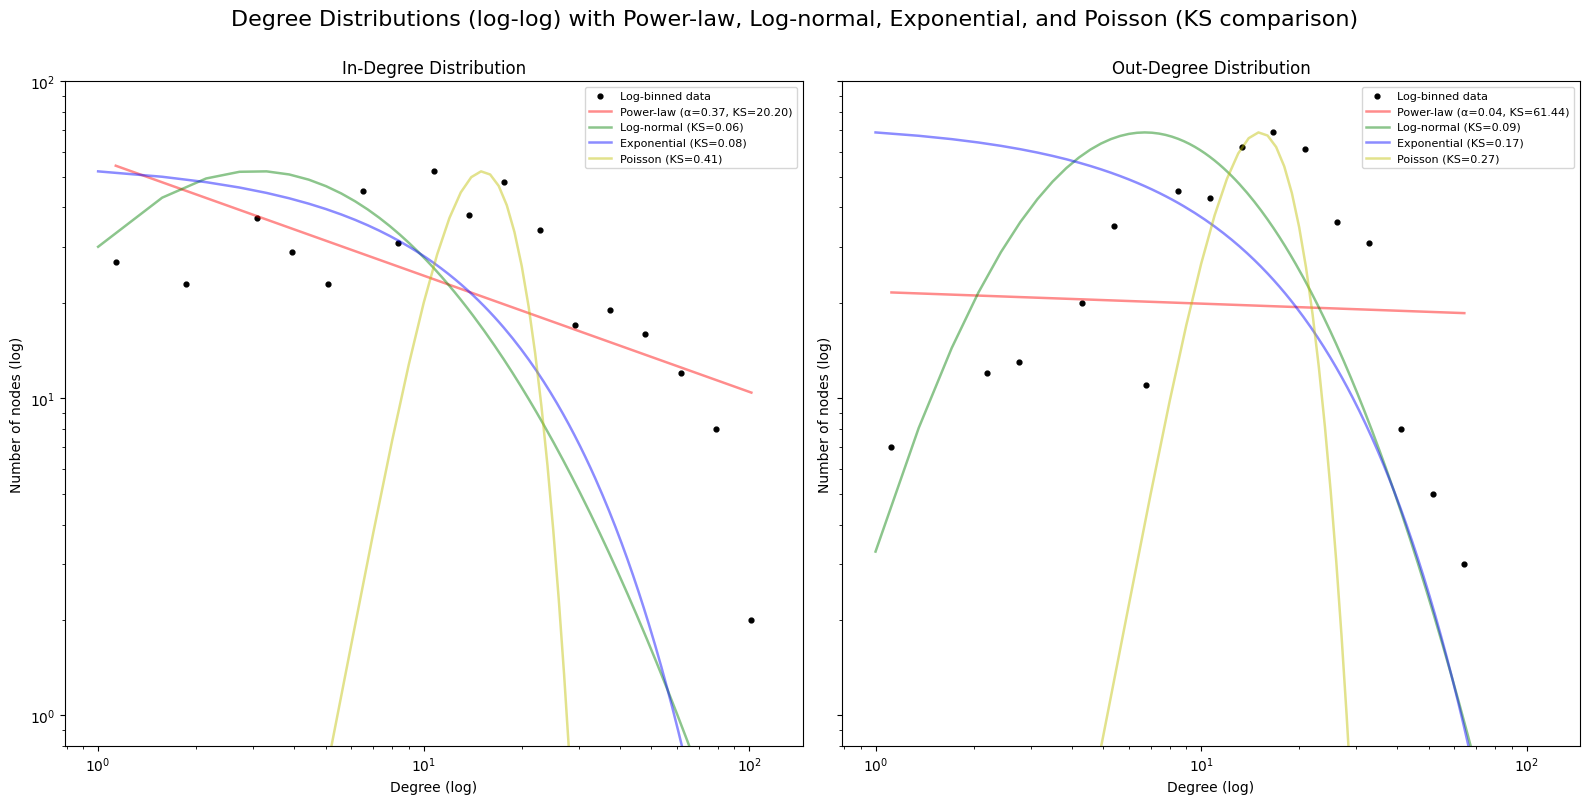

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

# ---- Run for in-degree and out-degree ----
fit_and_plot_logbinned(df['In Degree'], axs[0], 'In-Degree Distribution')
fit_and_plot_logbinned(df['Out Degree'], axs[1], 'Out-Degree Distribution')

plt.suptitle("Degree Distributions (log-log) with Power-law, Log-normal, Exponential, and Poisson (KS comparison)", y= 1, fontsize = 16)
plt.tight_layout()
plt.show()


>**Figure 1:** The plot shows the distributions of the In Degree (left) and the Out Degree (right). The distributions are shown on a log-log scale, and compared to the PDF of 4 different distributions, a Power-law Distribution, a Log-Normal Distribution, an Exponential Distribution and a Poisson Distribution. For both distributions the Log-Normal (green line) distributions has the best fit (KS = 0.06, KS = 0.09). 

### Correlation between In- and Out-Degrees
The following is a logical train of thought: The performers which have a high in-degree are very influential and famous. Given their fame, much will be written about them by their fans. The more content that is on a page, the more links it will include, and the higher the out-degree will be.  
This results in the folllowing hyppothesis: In-degree is correlated with content-length, content-length is correlated with out-degree and by extension, in-degree could be correlated with out-degree.  
The correlation between Content Length and respectively Out-Degrees and In-Degrees are 0.62 and 0.66. The partial correlation, controlling for Content Length is (0.32). Content Length explains a lot of the correlation, but even when removing it there is still a positive correlation between In- and Out-Degrees.

In [ ]:
df['Content Length'] = nx.get_node_attributes(DG, "content_length")

#Something about correlation between content-length and how it affects degrees
cor_cont_out = df['Content Length'].corr(df['Out Degree'], method = "pearson")
cor_cont_in = df['Content Length'].corr(df['In Degree'], method = "pearson")

# Partial correlation between In Degree and Out Degree controlling for Content Length
x = df['In Degree']
y = df['Out Degree']
z = df['Content Length']

# Regress out the effect of z from x and y
resid_x = stats.linregress(z, x).resid if hasattr(stats.linregress(z, x), 'resid') else x - stats.linregress(z, x).intercept - stats.linregress(z, x).slope * z
resid_y = stats.linregress(z, y).resid if hasattr(stats.linregress(z, y), 'resid') else y - stats.linregress(z, y).intercept - stats.linregress(z, y).slope * z

partial_corr = np.corrcoef(resid_x, resid_y)[0, 1]

# Print results
print(f"Correlation between Content Length and Out-Degrees: {cor_cont_out:.2f}")
print(f"Correlation between Content Length and In-Degrees: {cor_cont_in:.2f}")
print(f"Partial correlation between In- and Out-Degree (controlling for Content Length): {partial_corr:.2f}")

Correlation between Content Length and Out-Degrees: 0.62
Correlation between Content Length and In-Degrees: 0.66
Partial correlation between In- and Out-Degree (controlling for Content Length): 0.32


We evaluate the correlation between the In and Out-Degrees of the network using both Spearman and Pearson correlation. It has a Spearman-correlation of 0.67 and a Pearson correlation of 0.59. The distributions have a somewhat monotonic relationship, but it is more monotonic (0.67) than it is linear (0.57). There is however still a correlation. We also visually analyze this correlation with a scatterplot and a heatmap. The scatterplot shows the datapoints compared to a reference line with perfect correlation, and it becomes apparent that the observations do somewhat follow the reference line. To support the analysis we have plotted a heatmap. The heatmap clearly shows a higher density above the diagonal. There are more nodes which have a out-degree/in-degree ratio than vice-versa.

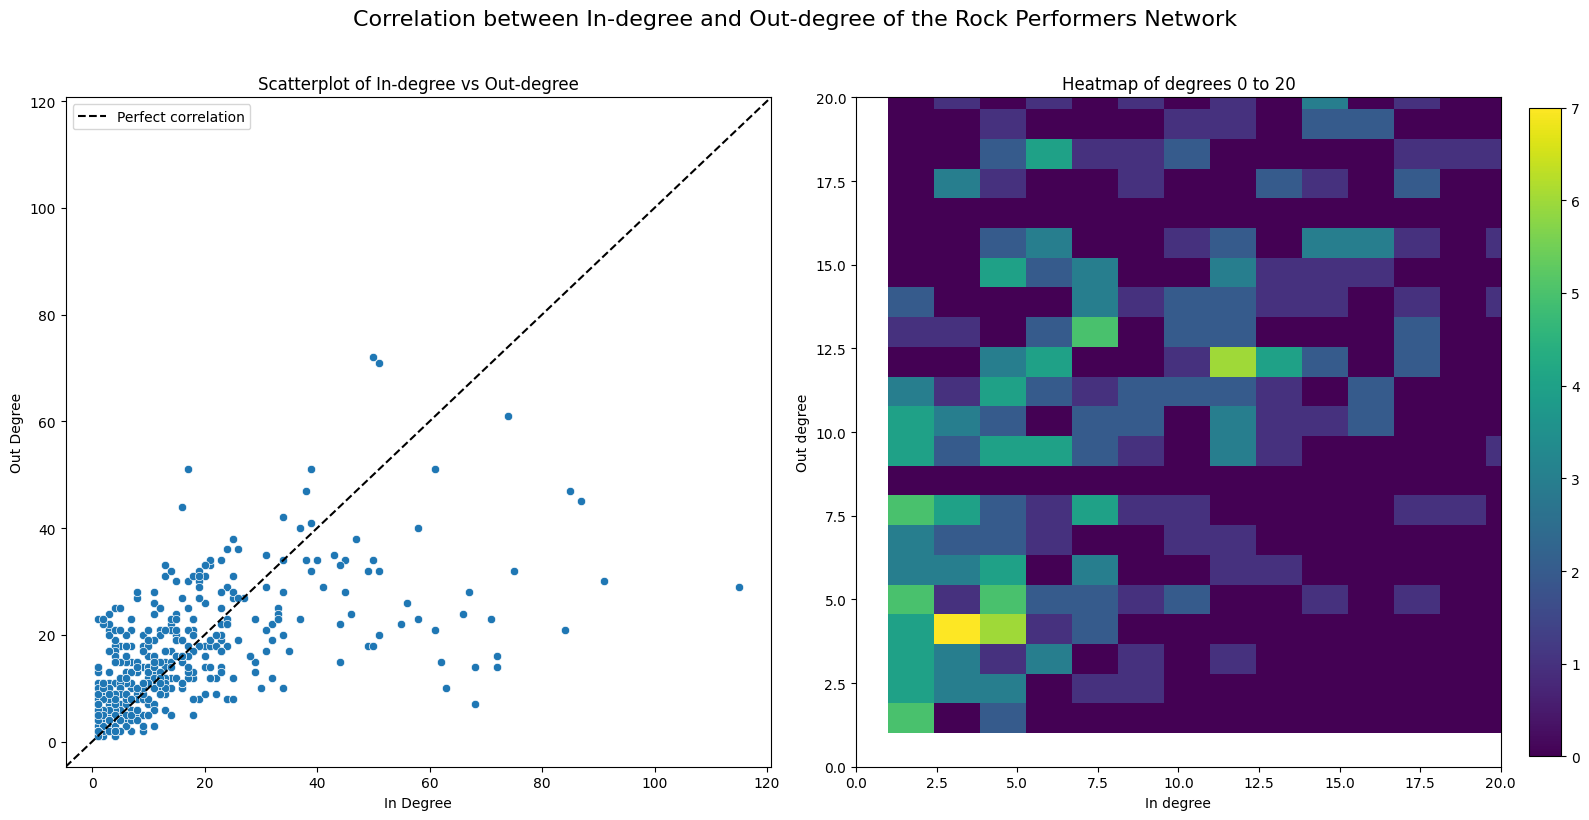

The Pearson correlation is 0.59 and the Spearman correlation is 0.67


In [ ]:
figure, axs = plt.subplots(1, 2, figsize=(16, 8))  # Row, col, w, h

# --- Scatterplot ---
sns.scatterplot(data=df, x="In Degree", y="Out Degree", ax=axs[0])

# Draw x = y line (perfect correlation reference)
lims = [
    np.min([axs[0].get_xlim(), axs[0].get_ylim()]),  # min of both axes
    np.max([axs[0].get_xlim(), axs[0].get_ylim()])   # max of both axes
]
axs[0].plot(lims, lims, color='black', linestyle='--', label='Perfect correlation')
axs[0].set_xlim(lims)
axs[0].set_ylim(lims)
axs[0].legend()
axs[0].set_title("Scatterplot of In-degree vs Out-degree")

# --- 2D Heatmap ---
heatmap_data, xedges, yedges = np.histogram2d(df["In Degree"], df["Out Degree"], bins=80)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

im = axs[1].imshow(heatmap_data.T, extent=extent, origin='lower', aspect='auto')
axs[1].set_xlabel("In degree")
axs[1].set_ylabel("Out degree")
axs[1].set_title("Heatmap of degrees 0 to 20")
axs[1].set_xlim(0, 20)
axs[1].set_ylim(0, 20)

# Optional colorbar
figure.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)

# --- Layout and title ---
plt.suptitle("Correlation between In-degree and Out-degree of the Rock Performers Network",
             y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# --- Correlations ---
cor_pearson = df['In Degree'].corr(df['Out Degree'], method="pearson")
cor_spearman = df['In Degree'].corr(df['Out Degree'], method="spearman")
print(f"The Pearson correlation is {cor_pearson:.2f} and the Spearman correlation is {cor_spearman:.2f}")


>**Figure 2:** The plots shows the correlation between the in-degrees of the network and the out-degrees of the network. The graph on the left shows a scatterplot of the degrees compared to reference line of perfect correlation, where out-degree equals in-degree. From the plot and the calculated measure it is apparent that the two are somewhat correlated. The heatmap (on the right) focuses on the area close to 0 (from 0 to 20 on both axis) and shows a very high density above the diagnoal. Nodes which do not have a high in-degree, are likely to have a higher out-degree than in-degree.

## 1.2 Centrality of the Network


To understand the centrality of the network, we calculate 3 different centrality measures, namely Degree Centrality, Betweenness Centrality and Eigenvector Centrality. In terms of interpreting these centrality measures in relation to the rock-network, Eigenvector centrality shows influence across the entire network, degree centrality can be centrality in a specific sub-genre and betweenness can be performers that connect sub-genres.  
Looking at the top 5 nodes for each centrality type we observe that a total of 8 nodes make up the overlap of the 3 measures. The overlap indicates that certain Performers dominate the network. Led Zeppelin has both the highest Degree Centrality and Eigenvector Centrality, while Deep Purple has the highest Betweenness Centrality. Additionally it can be seen by the table of Top Node Centralities that the overlap between Betweeness Centrality and Eigenvector Centrality is smaller than their respectice overlap with the Degree Centrality. In other words, the connection between how much a node connects the networks shortest paths, is less correlated with its importance in the network.  
This same conclusion can be reached by looking at the Pearson-correlation between the 3. There is a very high correlation between Degree Centrality and Eigenvector Centrality (0.92), slighly less for Degreee and Betweensness (0.875) and least for Betweeness and Eigenvector (0.775).  
This pattern of correlations makes sense, as eigenvector centrality is a type of smoothed version of degree centrality. Similarily high degree centrality increases the probability of being on the shortest path between two nodes, but eigenvector centrality and betweenness centrality share less similarities.

In [ ]:
df['Degree Centrality'] = nx.degree_centrality(DG)
df['Betweenness Centrality'] = nx.betweenness_centrality(DG)
df['Eigenvector Centrality'] = nx.eigenvector_centrality(DG)

df['Degree Centrality'] = df['Degree Centrality'].round(5)
df['Betweenness Centrality'] = df['Betweenness Centrality'].round(5)
df['Eigenvector Centrality'] = df['Eigenvector Centrality'].round(5)

top5_summary = pd.DataFrame({
    'Degree Centrality': df['Degree Centrality'].nlargest(5),
    'Betweenness Centrality': df['Betweenness Centrality'].nlargest(5),
    'Eigenvector Centrality': df['Eigenvector Centrality'].nlargest(5)
}).fillna("Not in top 5")


print(top5_summary.to_string(float_format="{:.3f}".format))

cor_Degree_Between = df['Degree Centrality'].corr(df['Betweenness Centrality'], method = "pearson")
cor_Degree_Eigen = df['Degree Centrality'].corr(df['Eigenvector Centrality'], method = "pearson")
cor_Between_Eigen = df['Betweenness Centrality'].corr(df['Eigenvector Centrality'], method = "pearson")

print(f"Correlation between Degree and Betweenness Centrality: {cor_Degree_Between:.3f}")
print(f"Correlation between Degree and Eigenvector Centrality: {cor_Degree_Eigen:.3f}")
print(f"Correlation between Betweenness and Eigenvector Centrality: {cor_Between_Eigen:.3f}")

                Degree Centrality Betweenness Centrality Eigenvector Centrality
Node                                                                           
Alice in Chains      Not in top 5                  0.036           Not in top 5
Black Sabbath               0.293                  0.035                  0.200
Deep Purple                 0.265                  0.046           Not in top 5
Jimi Hendrix         Not in top 5                  0.035           Not in top 5
Kiss (band)          Not in top 5           Not in top 5                  0.162
Led Zeppelin                0.313           Not in top 5                  0.225
Metallica                   0.287           Not in top 5                  0.188
Queen (band)                0.287                  0.041                  0.183
Correlation between Degree and Betweenness Centrality: 0.875
Correlation between Degree and Eigenvector Centrality: 0.920
Correlation between Betweenness and Eigenvector Centrality: 0.775


## 1.3 Assortativty of the Network
The network is somewhat neutral when it comes to Assortativity, both for In Degree (0.23) and Content Length (0.26), it is however more assortative than disassortative. We analyze assorativity with respect to in-degree, as in-degree is a stronger indicator of node significance than out-degree.  
The expectation from the network would probably be that both smaller (measured by in-degree) and bigger nodes tend to link to bigger nodes, which would result in a disassortative network.

In [ ]:
df['Avg Successor In-Degree'] = nx.average_neighbor_degree(DG, source = "out", target = "in") #What is the average in-degree of the successors to the node (of the nodes that the node points to)

avg_successor_content = {}

for node in DG.nodes():
    successors = list(DG.successors(node))
    if not successors:
        avg_successor_content[node] = np.nan
    else:
        avg_successor_content[node] = df.loc[successors, 'Content Length'].mean()

df['Avg Successor Content Length'] = df.index.map(avg_successor_content)


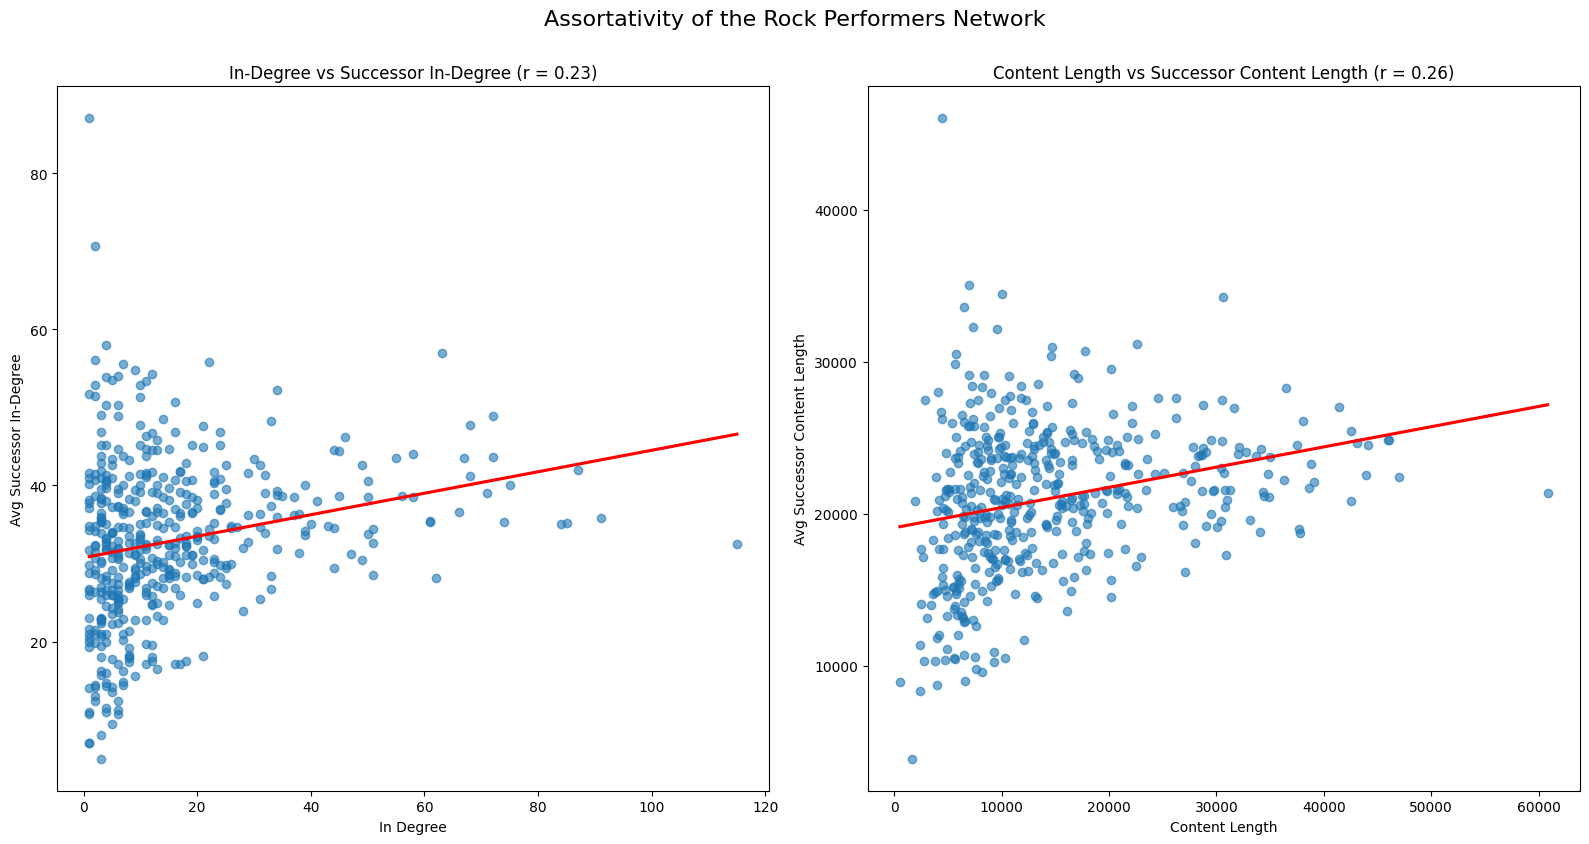

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# --- 1. In-degree vs Avg Successor In-degree. #Do the nodes with a high in-degree point to other nodes with high in-degree? No!
sns.regplot(
    data=df, x="In Degree", y="Avg Successor In-Degree", ax=axs[0]
    , scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ci=None)
r1, p1 = scipy.stats.pearsonr(df["In Degree"], df["Avg Successor In-Degree"])
axs[0].set_title(f"In-Degree vs Successor In-Degree (r = {r1:.2f})")


# --- 2. Content Length vs Avg Successor Content Length
sns.regplot(
    data=df, x="Content Length", y="Avg Successor Content Length", ax=axs[1]
    ,scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ci=None
)
r2, p2 = scipy.stats.pearsonr(df["Content Length"], df["Avg Successor Content Length"])
axs[1].set_title(f"Content Length vs Successor Content Length (r = {r2:.2f})")

plt.tight_layout()
plt.suptitle("Assortativity of the Rock Performers Network", y= 1.05, fontsize = 16)
plt.show()

>**Figure 3:** The plots show assortativity of the graph, measured by (on the left) In-Degree compared to Avg Successor In-Degree, and (right) content_length compared to Avg Successor Content Length. Both should be an indicator of the importance of the node. The graphs show slight assortativity (0.23 and 0.26) but is close to neutral. It is somewhat random if less important nodes point to nodes of same importance or to nodes of a different importance.

In [ ]:
louvain_communities = nx.community.louvain_communities(DG, weight='weight', seed = 42)

louvain_communities[0]
for com_idx, community in enumerate(louvain_communities):
    for node in community:
        df.at[node, 'Louvain Community'] = int(com_idx)

df.to_csv("graphs/node_df.csv", index = True)

## 1.4 Backbone and Visualization of the network
In our analysis of the network, we lastly visualize the network, through visualizing it's backbone, and coloring them by their Louvain Community. We will get back to the Louvian Communities later. The backbone is found as the High Salience Skeleton, only keeping the the edges with the top 10% salience scores (0.482), reducing the amount of edges from 7211 to 721. Only 8 nodes are removed, taking the network from 461 to 453 nodes.  
The salience of an edge refers to the fraction of shortest-path trees that use that edge.  
The network is hierarchical. Nodes with high eigenvector centrality (Overall influential on the network) also lies at the center of the High Salience Skeleton. The dominate the connectivity in the network, binding together performers and genres.  
Visual inspection of the network provides some clarity into its structure. John Lennon, Paul McCartney and The Beatles are placed somewhat close to eachother, but outside the center of network. Soundgarden and Nirvana are also grouped very closely together. At the center of the network we find performers like Elton John, Black Sabbath, Deep Purple.

In [ ]:
# Backbone calculations.
import backboning

g_df = nx.to_pandas_edgelist(DG, source = "src", target = "trg") #Construct edgelist df from graph
g_df.drop(columns = ['id'], inplace=True) #Drop the generated "id" column
g_df['nij'] = 1.0 #Set edge weight to 1

hss_df = backboning.high_salience_skeleton(g_df)

percentage_kept = 0.10 #What percentage of links are we keeping?

threshold_value = np.quantile(hss_df['score'], 1-percentage_kept) 

backbone_df = backboning.thresholding(hss_df, threshold_value)

HSS_G = nx.from_pandas_edgelist(df = backbone_df, source = "src", target= "trg", edge_attr="score"
                                , create_using=nx.DiGraph)

n_nodes = len(HSS_G.nodes())
n_edges = len(HSS_G.edges())
print(f"The High Salience Skeleton consists of {n_nodes} nodes and {n_edges} edges, where the edges have a salience score above {threshold_value}")


Calculating HSS score...


The High Salience Skeleton consists of 453 nodes and 721 edges, where the edges have a salience score above 0.48156182212581344


c:\Users\ThorNørgaardEriksen\OneDrive - Intellishore\3. Privat\2. Studie\2. Kurser\02805 - Social Graphs\socialgraphs\Lib\site-packages\networkx\drawing\layout.py:1809: RuntimeWarning: invalid value encountered in divide
  attraction = -np.log(1 + distance) / distance


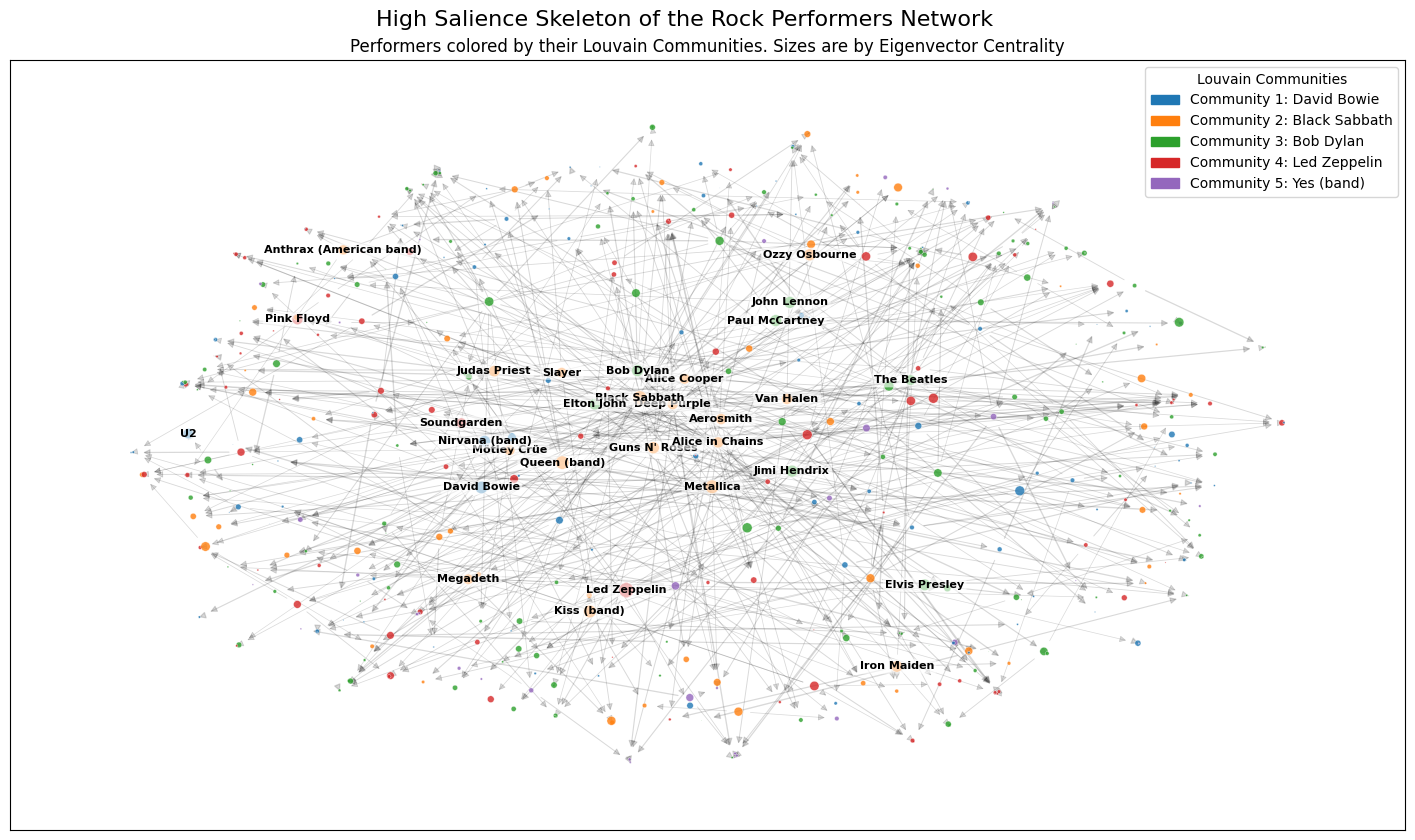

In [ ]:
HSS_G_node_sizes = (df['Eigenvector Centrality']
           .reindex(HSS_G.nodes())      # align order to the graph
           .fillna(0)                   # 0 if a node is missing in df
           .astype(float)
           .to_numpy() * 500)             # scale factor

HSS_G_hubs = df['Eigenvector Centrality'].sort_values(ascending=False).head(30)
HSS_G_label_nodes = set(HSS_G_hubs.index)

edge_weights = [weight for (u,v), weight in nx.get_edge_attributes(HSS_G, 'score').items()]

#Plot settings
figure, axs = plt.subplots(1,1,figsize = (18,10)) #Width, Height

nx.set_edge_attributes(HSS_G, 
    {edge: d.get('score', 1.0) for edge, d in HSS_G.edges.items()}, 
    'weight'
)

#Colors
colors = []
for node in HSS_G.nodes(): ########################################################     CHANGE THIS SECTION FOR PLOTTING FOR DIFFERENT COMMUNITIES
    colors.append(cm.tab10(int(df.loc[node, 'Louvain Community'])))

#Find a top node for each of the communities
top_nodes = {}
for community_id in df['Louvain Community'].unique():
    top_node = df[df['Louvain Community'] == community_id]['Degree Centrality'].idxmax(axis = 0)
    top_nodes.update({community_id: top_node})

# --- Legend for top communities (representative node = hub) ---
legend_handles = []
for com_idx, community in enumerate(louvain_communities):
    top_node = top_nodes[com_idx]
    legend_handles.append(
        mpatches.Patch(color=cm.tab10(com_idx % 10), label=f"Community {com_idx+1}: {top_node}")
    )

# --- Add legend ---
plt.legend(handles=legend_handles, title="Louvain Communities")


#################################################################################### STANDARD PLOTTING
#Get the force atlas positions
force_positions = nx.forceatlas2_layout(HSS_G
                                        ,scaling_ratio = 1
                                        ,gravity=0.1 #This is cool
                                        ,linlog = True #I LIKE THIS BUT I NEED TO EXPLAIN IT
                                        # ,distributed_action=True #EXPLAIN WHAT THIS DOES
                                        , seed = 42
                                        )

#Draw edges
nx.draw_networkx_edges(HSS_G, pos = force_positions, alpha = 0.15, edge_color = "k", ax=axs
                       , width=edge_weights
                       )

#Draw nodes
nx.draw_networkx_nodes(HSS_G, pos = force_positions, alpha = 0.8, edgecolors = "white", linewidths = 0.3, ax=axs
                       , node_size=HSS_G_node_sizes, node_color=colors
                       )


nx.draw_networkx_labels(
    HSS_G,
    ax=axs,
    pos=force_positions,              # or use force_positions directly
    labels={node:node if node in HSS_G_label_nodes else '' for node in HSS_G.nodes()},            # only these nodes will get text
    font_size=8,
    font_weight="bold",
    font_color="black",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6)  # improves readability
)

plt.suptitle("High Salience Skeleton of the Rock Performers Network", y= 0.93, fontsize = 16)
plt.title("Performers colored by their Louvain Communities. Sizes are by Eigenvector Centrality")
plt.show()

>**Figure 4:** The plot shows the High Salience Skeleton of the Rock Performers Network, colored by Louvain Communities and Sized by Eigenvector Centrality. Reducing the network to the top 10% most important edges with regards to salience leaves 453 nodes and 721 edges. There is a general pattern of the nodes with the highest Eigenvector Centrality lie at the center of the High Salience Skeleton, connecting many different nodes.

## 1.5 Short Summary of the Network Analysis
The network represents interactions between the wikipedia pages of mainstream rock performers. The network consists of a directed graph 461 nodes, with the networks degree distributions following log-normal distribution, indicating a slight tendency to preferential attachment but ultimately being a result of multiple factors. There is a correlation between in-degrees and out-degrees of the network even when controlling for content length. 8 Artist dominate the network across different centrality measures, with Led Zeppelin haivng the highest score of both Degree Centrality and Eigenvector Centrality. The network is not assortative to either content length or in-degrees, both indicators of the importance of a node. When the backbone of the network, based on the High Salience Skeleton, is visualized, some grouping appear, like John Lennon and Paul McCartney, Nirvana and Soundgarden etc.

# Part 1: Analyze the Network

This section presents an analysis of the network of bands/artists using concepts from network science, including centrality measures, assortativity, and network backbones.

## 1.1 Network Overview and Basic Properties

## 1.2 Degree Distribution Analysis

## 1.3 Centrality Analysis

## 1.4 Assortativity Analysis

## 1.5 Network Backbone Construction

## 1.6 Network Visualization

## 1.7 Summary of Network Characteristics

---

# Part 2: Genres and Communities and Plotting

This section explores the relationship between musical genres and detected communities, examining modularity and creating visualizations.

## 2.1 Genres and Modularity
The modularity describes how a community structure in a network is more or less strongly divided than if we just made the communities at random. So if the communities have more of their edges internally than would be expected from a randomly wired network of the same N nodes and L links it gets a positive modularity. On the other hand, a community definition which splits more edges between communities than the random wiring will have a negative modularity.

Shown in [Barabasi - Image 9.16] are two different community partitions. In partition **a** most edges stay within communities (only 1 edge crosses between green and purple), giving M = 0.41. In partition **b**, more edges cross between communities (3 edges), resulting in lower modularity M = 0.22. Both outperform random (M $\approx$ 0), but **a** is the better partition. **d** which only has inter

Using the measure of modularity we can now quantify how well our previous partitions perform on our Rock network compared to the genres defined on the wiki-page of the artist.

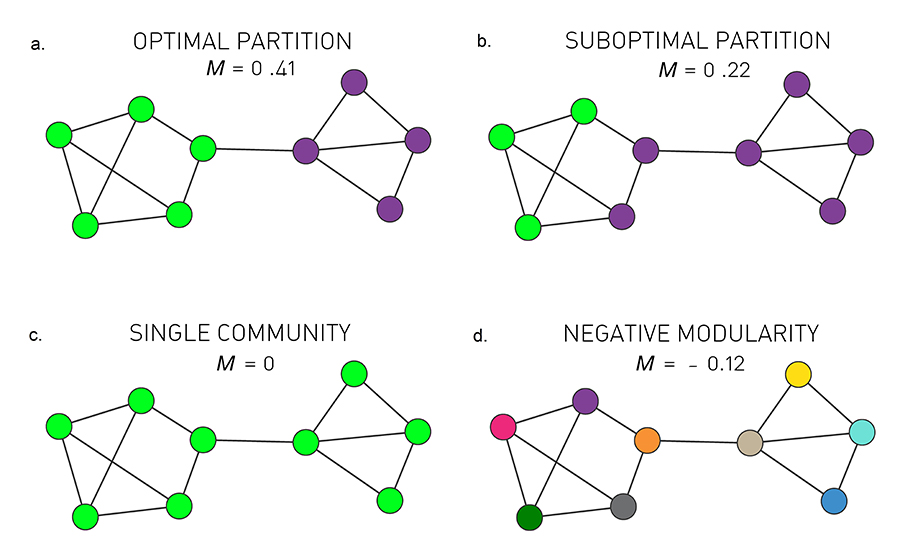

**Reference:** Barabási, A.-L. (2016). Network Science, Chapter 9, Section 9.4 and Image 9.16

First we define the function to find the modularity based on Barabási equation $(9.11)$ and $(9.12)$

In [37]:
def calculate_modularity(G, communities, verbose=False):
    """
    Compute Newman-Girvan modularity for an undirected graph G given a partition.
    """
    
    L = G.number_of_edges()
    M = 0
    
    for community_label, nodes in communities.items():
        # Internal edges in community
        Lc = G.subgraph(nodes).number_of_edges()
        
        # Sum of degrees in community
        kc = sum(G.degree(node) for node in nodes if node in G)
        
        left = Lc / L
        right = (kc / (2 * L)) ** 2
        Mc = left - right
        M += Mc
        
        if verbose:
            print(f"Community '{community_label}':")
            print(f"  Internal edges (Lc): {Lc}")
            print(f"  Total degree (kc): {kc}")
            print(f"  Modularity contribution (Mc): {Mc:.4f}")    
    return M

## 2.3 Modularity Comparison: Communities vs. Genres

In Section 1 we found the structural communities in the network by using the Louvain Community Detection Algorithm, before we can compare them to the genre definitions we need to retrieve those from the .txt files. After that, they're added to the data-frame. We create two columns: One is the first genre mentioned in the list, the second is made by assigning a random genre from all the ones mentioned.

In [59]:
with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/graphs/rock_bands_graph.gexf") as response:
    DG = nx.read_gexf(response)

G = DG.to_undirected()

with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/graphs/node_df.csv") as response:
    node_df = pd.read_csv(response)

def extract_genres(text):
    """Extract genres from Wikipedia infobox text."""
    # Remove HTML comments
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)
    
    # Find infobox
    infobox = re.search(r'\{\{Infobox musical artist(.*?)(?=\n\{\{[^I]|\Z)', text, re.DOTALL)
    if not infobox:
        return []
    
    # Find genre field
    lines = infobox.group(1).split('\n')
    genre_lines = []
    in_genre = False
    
    for line in lines:
        if line.strip().startswith('|'):
            field = re.match(r'\|\s*(\w+)\s*=', line)
            if field and field.group(1) == 'genre':
                in_genre = True
                genre_lines.append(line.split('=', 1)[1] if '=' in line else '')
            else:
                in_genre = False
        elif in_genre and not line.strip().startswith('}}'):
            genre_lines.append(line)
    
    if not genre_lines:
        return []
    
    # Extract wikilinks
    genre_text = '\n'.join(genre_lines)
    genre_text = re.sub(r'<ref[^>]*>.*?</ref>', '', genre_text, flags=re.DOTALL)
    
    genres = []
    for link in re.findall(r'\[\[([^\]]+?)\]\]', genre_text):
        genre = link.split('|')[-1] if '|' in link else link
        genre = re.sub(r'\s*\([^)]*\)', '', genre).strip()
        
        # Skip non-genres
        skip = ['Records', 'Label', 'Music', 'Radio', 'Journal', 'Magazine']
        if genre and not any(s in genre for s in skip):
            genres.append(genre)
    
    return genres


def parse_artist_files(directory):
    """Parse all artist .txt files in a directory. Returns dict: {artist_name: [genres]}"""
    artist_genres = {}
    
    for file_path in Path(directory).glob("*.txt"):
        # Get artist name from filename
        name = file_path.stem
        name = re.sub(r'^\d+_', '', name)  # Remove timestamp
        name = name.replace('_20', ' ').replace('_28', '(').replace('_29', ')')
        
        if name in artist_genres:  # Skip duplicates
            continue
        
        with open(file_path, 'r', encoding='utf-8') as f:
            artist_genres[name] = extract_genres(f.read())
    
    return artist_genres

# Parse files (parse_artist_files is defined in an earlier cell)
artist_genres = parse_artist_files('rock_data')

# Normalize possible percent-encoded or underscore-encoded filenames to readable artist names
fixed_artist_genres = {}
for artist, genres in artist_genres.items():
    name = unquote(artist)                         # decode percent-encoding (e.g. %20 -> space)
    name = name.replace('_20', ' ').replace('_28', '(').replace('_29', ')')
    name = re.sub(r'^\d+_', '', name)             # remove leading timestamp if present
    fixed_artist_genres[name] = genres


# Parse files (parse_artist_files is defined in an earlier cell)
artist_genres = parse_artist_files('rock_data')

# Normalize possible percent-encoded or underscore-encoded filenames to readable artist names
fixed_artist_genres = {}
for artist, genres in artist_genres.items():
    name = unquote(artist)                         # decode percent-encoding (e.g. %20 -> space)
    name = name.replace('_20', ' ').replace('_28', '(').replace('_29', ')')
    name = re.sub(r'^\d+_', '', name)             # remove leading timestamp if present
    fixed_artist_genres[name] = genres


# Add genre columns to node_df
node_df['first_genre'] = node_df['Node'].apply(
    lambda x: fixed_artist_genres.get(x, [None])[0] if fixed_artist_genres.get(x, []) else None
)

node_df['random_genre'] = node_df['Node'].apply(
    lambda x: random.choice(fixed_artist_genres.get(x, [None])) if fixed_artist_genres.get(x, []) else None
)

In [60]:
node_df

,Node,In Degree,Out Degree,Degree Centrality,Betweenness Centrality,Eigenvector Centrality,Avg Neighbour Degree,Content Length,Louvain,first_genre,random_genre
0,10 Years (band),7,10,0.03696,0.00089,0.01243,23.900000,4501,3.0,Alternative metal,progressive metal
1,Disturbed (band),20,33,0.11522,0.00462,0.03755,23.787879,11700,3.0,Heavy metal,hard rock
2,Breaking Benjamin,21,33,0.11739,0.00648,0.02216,22.303030,16494,3.0,Hard rock,alternative rock
3,Mudvayne,7,15,0.04783,0.00038,0.01956,33.333333,7843,1.0,Alternative metal,nu metal
4,Korn,38,34,0.15652,0.00876,0.08627,26.205882,30035,3.0,Nu metal,alternative metal
...,...,...,...,...,...,...,...,...,...,...,...
456,The Jesus and Mary Chain,1,13,0.03043,0.00035,0.00310,15.307692,9465,0.0,Noise pop,indie rock
457,Smash Mouth,1,14,0.03261,0.00019,0.00027,18.571429,9336,3.0,Alternative rock,pop rock
458,Smokie (band),1,2,0.00652,0.00010,0.00157,17.500000,4730,4.0,Pop rock,Pop rock
459,The Fray,2,11,0.02826,0.00025,0.00112,14.545455,8889,0.0,Alternative rock,soft rock


To avoid skewing the results unfairly towards the Louvain results, we need to handle nodes which are missing genre information (either through imprecise scraping or lack of genres in the article). Since they account for only 5% of the network we chose to drop them.

In [61]:
filtered_nodes_df = node_df.dropna(subset=['first_genre'])

In [63]:
# Create three different community partitions

# 1. Louvain communities
louvain_communities = {}
for _, row in filtered_nodes_df.iterrows():
    community_label = f"Louvain_{int(row['Louvain'])}"
    if community_label not in louvain_communities:
        louvain_communities[community_label] = []
    louvain_communities[community_label].append(row['Node'])

# 2. First genre communities
first_genre_communities = {}
for _, row in filtered_nodes_df.iterrows():
    if pd.notna(row['first_genre']):
        genre = row['first_genre']
        if genre not in first_genre_communities:
            first_genre_communities[genre] = []
        first_genre_communities[genre].append(row['Node'])

# 3. Random genre communities
random_genre_communities = {}
for _, row in filtered_nodes_df.iterrows():
    if pd.notna(row['random_genre']):
        genre = row['random_genre']
        if genre not in random_genre_communities:
            random_genre_communities[genre] = []
        random_genre_communities[genre].append(row['Node'])

# Calculate modularity for each partition
modularity_louvain = calculate_modularity(G, louvain_communities, verbose=False)

modularity_first_genre = calculate_modularity(G, first_genre_communities, verbose=False)

modularity_random_genre = calculate_modularity(G, random_genre_communities, verbose=False)

# Create a summary dataframe
modularity_summary = pd.DataFrame({
    'Partition': ['Louvain', 'First Genre', 'Random Genre'],
    'Modularity': [modularity_louvain, modularity_first_genre, modularity_random_genre],
    'Num Communities': [len(louvain_communities), len(first_genre_communities), 
                        len(random_genre_communities)]
})

# Print summary statistics
print("Community Partition Summary:")
print(modularity_summary.to_string(index=False))

Community Partition Summary:
   Partition  Modularity  Num Communities
     Louvain    0.301791                5
 First Genre    0.087014               77
Random Genre    0.017266              139


The structural community (M = 0.302) dramatically outperforms both genre-based partitions. The Louvain algorithm identifies 5 cohesive communities, while genre classifications fragment the network into 77-139 disconnected groups with poor modularity.

When randomly assigning genres to artists (M = 0.017, 139 communities), modularity approaches zero. This shows that meaningful partitions require actual network structure, not labels that are assigned according the what wiki-editor happend to associate them with. The first-genre partition (M = 0.087) performs better than random but still fails to capture the network's proper organization.

The $\approx 3.5x$ improvement in modularity (0.302 vs 0.087) demonstrates that using the inherent structure of the network (who connects with whom), reveals that the community structure is far better than editorial genre classifications made by wikipedia editors.

## 2.4 Calculating and Analyzing Matrix D

Top 7 genres:
  Rock: 64
  Alternative rock: 57
  Hard rock: 50
  Pop rock: 19
  Heavy metal: 16
  Progressive rock: 15
  Rock and roll: 13

Top 7 communities:
  Louvain_2: 144 nodes
  Louvain_0: 111 nodes
  Louvain_3: 96 nodes
  Louvain_1: 68 nodes
  Louvain_4: 42 nodes


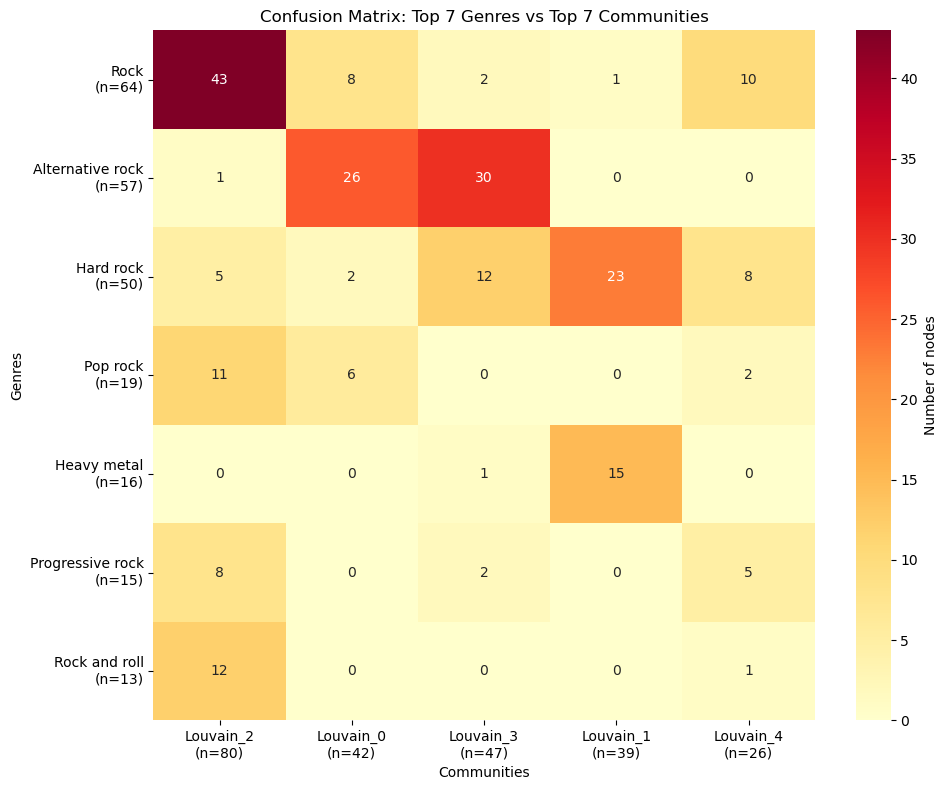

In [64]:
# Count how many artists belong to each genre
genre_counts = Counter()
for _, row in node_df.iterrows():
    if pd.notna(row['first_genre']):
        genre_counts[row['first_genre']] += 1

# Get top 7 genres
G = genre_counts.most_common(7)

# Get top 7 communities from Louvain (based on size)
louvain_counts = node_df['Louvain'].value_counts()
C = [(f"Louvain_{int(comm)}", count) for comm, count in louvain_counts.head(7).items()]

# Print top 7 genres and communities
print("Top 7 genres:")
for genre, count in G:
    print(f"  {genre}: {count}")

print(f"\nTop 7 communities:")
for label, size in C:
    print(f"  {label}: {size} nodes")

# Create confusion matrix D (G x C)

# Extract just the names
top_genres = [g[0] for g in G]
top_communities = [c[0] for c in C]

# Initialize confusion matrix
D = np.zeros((len(top_genres), len(top_communities)))

# Fill confusion matrix
for i, genre in enumerate(top_genres):
    for j, comm_label in enumerate(top_communities):
        # Count nodes that have this genre AND are in this community
        count = len(node_df[
            (node_df['first_genre'] == genre) & 
            (node_df['Louvain'] == int(comm_label.split('_')[1]))
        ])
        
        D[i, j] = count

# Calculate row and column sums
row_sums = D.sum(axis=1)
col_sums = D.sum(axis=0)

# Create labels with sums
row_labels = [f"{genre}\n(n={int(s)})" for genre, s in zip(top_genres, row_sums)]
col_labels = [f"{comm}\n(n={int(s)})" for comm, s in zip(top_communities, col_sums)]

# Create DataFrame for better visualization
D_df = pd.DataFrame(D, index=row_labels, columns=col_labels)

# Visualize as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(D_df, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Number of nodes'})
plt.title('Confusion Matrix: Top 7 Genres vs Top 7 Communities')
plt.xlabel('Communities')
plt.ylabel('Genres')
plt.tight_layout()
plt.show()


The confusion matrix shows how well the structural communities capture the different genres, if they align perfectly we would see all 

## 2.5 Visualization of Communities

Using the backbone from part 1, the new communities are illustrated. For genres only the top 7 are colored. Code is folded as it varies very little from the earlier plotting.

In [195]:
# Backbone calculations.
import backboning

g_df = nx.to_pandas_edgelist(DG, source = "src", target = "trg") #Construct edgelist df from graph
g_df.drop(columns = ['id'], inplace=True) #Drop the generated "id" column
g_df['nij'] = 1.0 #Set edge weight to 1

hss_df = backboning.high_salience_skeleton(g_df)

percentage_kept = 0.10 #What percentage of links are we keeping?

threshold_value = np.quantile(hss_df['score'], 1-percentage_kept) 

backbone_df = backboning.thresholding(hss_df, threshold_value)

HSS_G = nx.from_pandas_edgelist(df = backbone_df, source = "src", target= "trg", edge_attr="score"
                                , create_using=nx.DiGraph)

Calculating HSS score...


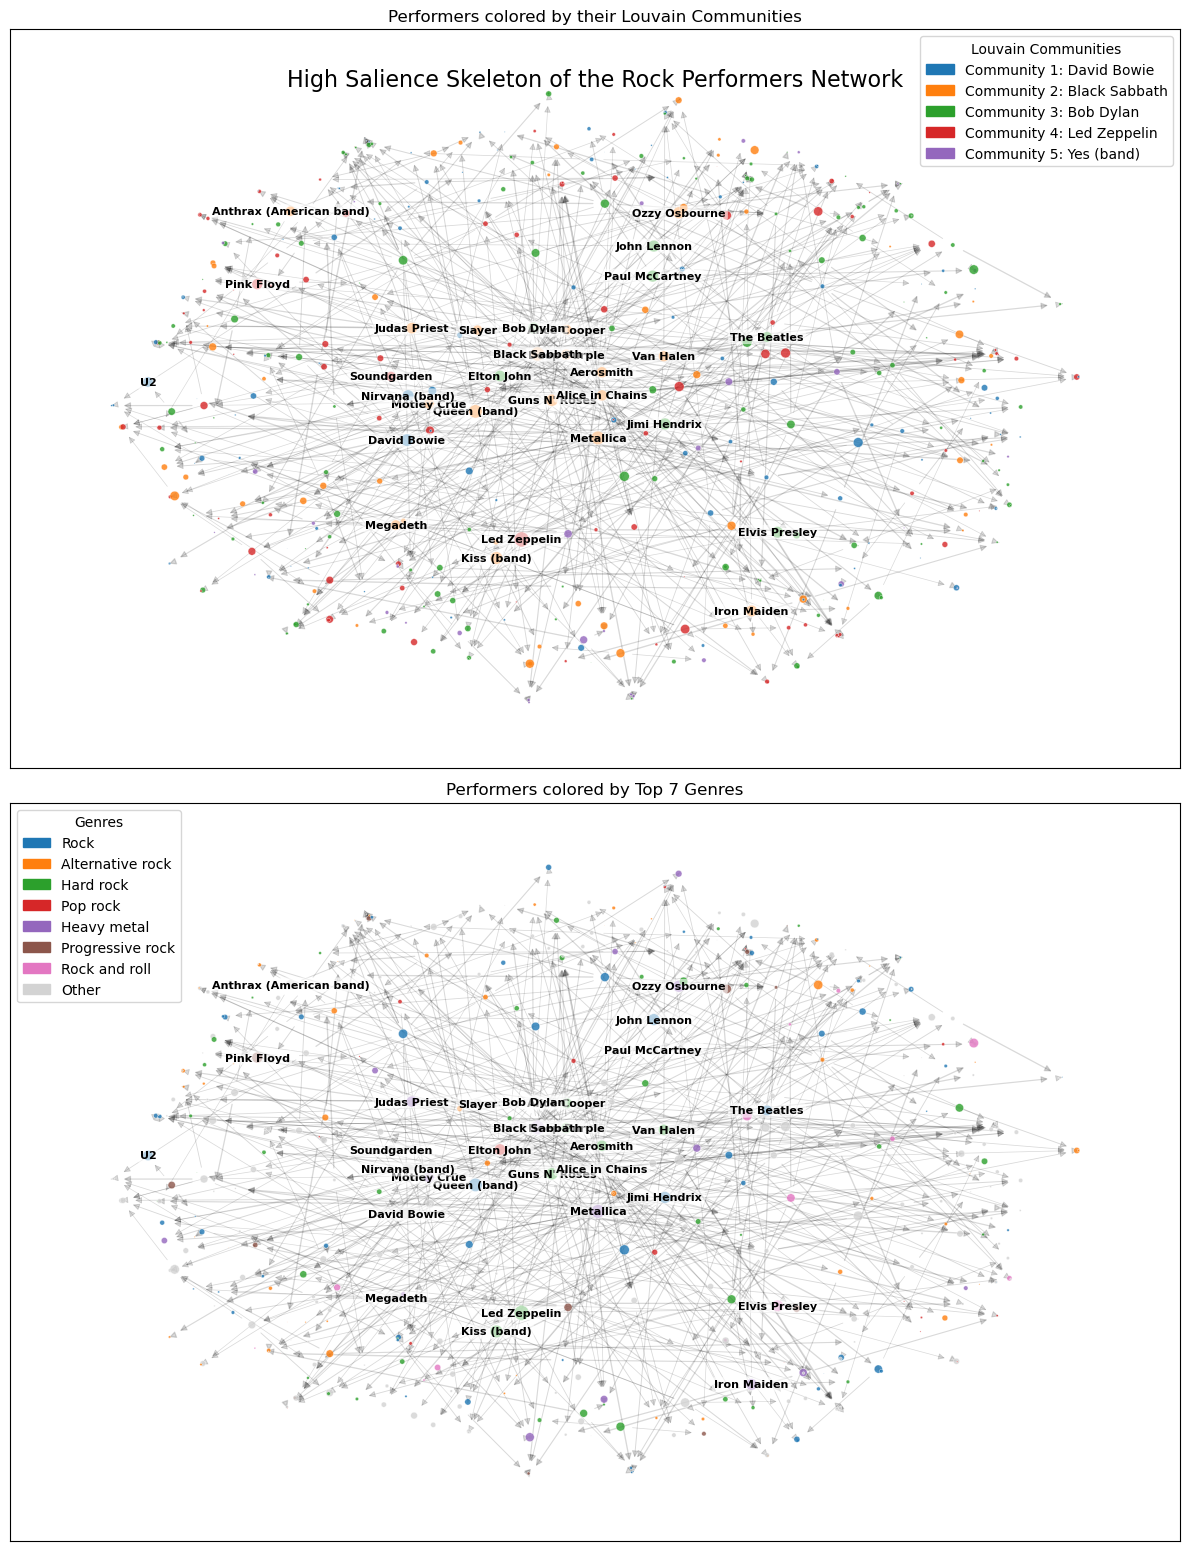

In [207]:
df = node_df.copy()

HSS_G_node_sizes = (df['Eigenvector Centrality']
           .reindex(HSS_G.nodes())      # align order to the graph
           .fillna(0)                   # 0 if a node is missing in df
           .astype(float)
           .to_numpy() * 500)             # scale factor

HSS_G_hubs = df['Eigenvector Centrality'].sort_values(ascending=False).head(30)
HSS_G_label_nodes = set(HSS_G_hubs.index)

edge_weights = [weight for (u,v), weight in nx.get_edge_attributes(HSS_G, 'score').items()]

#Plot settings
figure, axs = plt.subplots(2, 1, figsize=(12, 16))  # 2 rows, 1 column

nx.set_edge_attributes(HSS_G, 
    {edge: d.get('score', 1.0) for edge, d in HSS_G.edges.items()}, 
    'weight'
)

# ========== FIRST PLOT: Louvain Communities ==========
#Colors
colors = []
for node in HSS_G.nodes():
    colors.append(cm.tab10(int(df.loc[node, 'Louvain'])))

#Find a top node for each of the communities
top_nodes = {}
for community_id in df['Louvain'].unique():
    top_node = df[df['Louvain'] == community_id]['Degree Centrality'].idxmax(axis = 0)
    top_nodes.update({community_id: top_node})

# Legend for top communities
legend_handles = []
for com_idx, community in enumerate(louvain_communities):
    top_node = top_nodes[com_idx]
    legend_handles.append(
        mpatches.Patch(color=cm.tab10(com_idx % 10), label=f"Community {com_idx+1}: {top_node}")
    )

axs[0].legend(handles=legend_handles, title="Louvain Communities")

#Get the force atlas positions
force_positions = nx.forceatlas2_layout(HSS_G
                                        ,scaling_ratio = 1
                                        ,gravity=0.1
                                        ,linlog = True
                                        ,seed=42
                                        )

#Draw edges
nx.draw_networkx_edges(HSS_G, pos = force_positions, alpha = 0.15, edge_color = "k", ax=axs[0]
                       , width=edge_weights
                       )

#Draw nodes
nx.draw_networkx_nodes(HSS_G, pos = force_positions, alpha = 0.8, edgecolors = "white", linewidths = 0.3, ax=axs[0]
                       , node_size=HSS_G_node_sizes, node_color=colors
                       )

nx.draw_networkx_labels(
    HSS_G,
    ax=axs[0],
    pos=force_positions,
    labels={node:node if node in HSS_G_label_nodes else '' for node in HSS_G.nodes()},
    font_size=8,
    font_weight="bold",
    font_color="black",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6)
)

axs[0].set_title("Performers colored by their Louvain Communities")

# ========== SECOND PLOT: Top 7 Genres ==========
# Map top 7 genres to colors
genre_to_color = {genre: i for i, genre in enumerate(top_genres)}

# Colors based on first_genre
colors = []
for node in HSS_G.nodes():
    node_genre = df.loc[node, 'first_genre']
    if pd.notna(node_genre) and node_genre in genre_to_color:
        colors.append(cm.tab10(genre_to_color[node_genre]))
    else:
        colors.append('lightgray')

# Legend for top 7 genres
legend_handles = []
for genre in top_genres:
    legend_handles.append(
        mpatches.Patch(color=cm.tab10(genre_to_color[genre]), label=genre)
    )
legend_handles.append(mpatches.Patch(color='lightgray', label='Other'))

axs[1].legend(handles=legend_handles, title="Genres", loc='upper left')

#Draw edges
nx.draw_networkx_edges(HSS_G, pos = force_positions, alpha = 0.15, edge_color = "k", ax=axs[1]
                       , width=edge_weights
                       )

#Draw nodes
nx.draw_networkx_nodes(HSS_G, pos = force_positions, alpha = 0.8, edgecolors = "white", linewidths = 0.3, ax=axs[1]
                       , node_size=HSS_G_node_sizes, node_color=colors
                       )

nx.draw_networkx_labels(
    HSS_G,
    ax=axs[1],
    pos=force_positions,
    labels={node:node if node in HSS_G_label_nodes else '' for node in HSS_G.nodes()},
    font_size=8,
    font_weight="bold",
    font_color="black",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6)
)

axs[1].set_title("Performers colored by Top 7 Genres")

plt.suptitle("High Salience Skeleton of the Rock Performers Network", y=0.93, fontsize=16)
plt.tight_layout()
plt.show()


---

# Part 3: TF-IDF to Understand Genres and Communities

This section applies TF-IDF (Term Frequency-Inverse Document Frequency) analysis to understand the linguistic characteristics of genres and communities.

## 3.1 Explanation of TF-IDF

When analysing the found communities an interesting aspect is the linguistical characteristics that they share, but even more interesting are the contrasts between the various communities. Working with the Wikipedia-articles as a proxy of what defines a band and aggregating that across our communities allows us the use of TF-IDF to say what words are particularly important for each community.

TF-IDF works by multiplying the term frequency (TF) which is a measure of how many times the term appears in a document (With the document here being the collected articles across the community) with the inverse document frequency (IDF) which measures how common the word is across the entire corpus (Every article in the entire network). This way very frequent words like band or album which have the highest TF in all communities but tell us nothing about the differences are filtered out because even if they have very high TF their IDF is 0 ($ln(1)$). In contrast, a term which occurs much less frequently across the corpus, but has a higher IDF must mean that the term is endemic to this specific community, which is a lot more interesting for our analysis.

## 3.2 TF-IDF Calculation for Genres

In [220]:
from nltk.corpus import words

# Ensure required NLTK data is available
try:
    nltk.data.find('corpora/wordnet')
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('wordnet')
    nltk.download('punkt')
    nltk.download('stopwords')

def simple_lemmatize(word):
    """Lemmatize by trying noun, verb, and adjective forms"""
    lemmatizer = WordNetLemmatizer()
    # Try as noun first (most common)
    lemma = lemmatizer.lemmatize(word, pos='n')
    if lemma == word:
        # If unchanged, try as verb
        lemma = lemmatizer.lemmatize(word, pos='v')
    if lemma == word:
        # If still unchanged, try as adjective
        lemma = lemmatizer.lemmatize(word, pos='a')
    return lemma

def preprocess_text(text):
    """Clean and tokenize text"""
    text = re.sub(r'\{\{[^}]*\}\}', '', text)  # Remove templates
    text = re.sub(r'\[\[([^\]|]+\|)?([^\]]+)\]\]', r'\2', text)  # Remove wiki links
    text = re.sub(r'<[^>]+>', '', text)  # Remove HTML tags
    text = re.sub(r'&[a-zA-Z]+;', '', text)  # Remove HTML entities
    text = re.sub(r'[^\w\s]', ' ', text)  # Remove punctuation
    text = text.lower()  # Convert to lowercase
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Lemmatize
    tokens = [simple_lemmatize(token) for token in tokens]

    # Filter and clean tokens for stopwords and tokens <= 2 characters
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens 
              if len(token) > 2 and token not in stop_words]
    
    return tokens

def calculate_tfidf_for_communities(communities_dict, top_n=10):
    """
    Calculate TF-IDF scores for communities based on artist Wikipedia articles.
    
    Parameters:
    communities_dict: dict mapping community labels to lists of artist names
    top_n: int, number of top words to return for each community
    
    Returns:
    dict: mapping community labels to lists of (word, tfidf_score) tuples
    """
    # Step 1: Collect and tokenize documents for each community
    community_labels = []
    community_tokens = {}  # {community: [list of tokens]}
    
    for community_label, artists in communities_dict.items():
        all_tokens = []
        
        for artist in artists:
            filename = urllib.parse.quote(artist, safe="") + ".txt"
            file_path = os.path.join("rock_data", filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    content = f.read()
                    tokens = preprocess_text(content)
                    all_tokens.extend(tokens)
            except FileNotFoundError:
                print(f"Warning: Could not find file for artist '{artist}'")
                continue
            except Exception as e:
                print(f"Warning: Could not process file for artist '{artist}': {e}")
                continue
        
        if all_tokens:
            community_tokens[community_label] = all_tokens
            community_labels.append(community_label)
    
    # Step 2: Calculate TF (Term Frequency) for each community
    community_tf = {}
    for community, tokens in community_tokens.items():
        token_counts = Counter(tokens)
        total_tokens = len(tokens)
        # TF = count / total_tokens
        tf = {word: count / total_tokens for word, count in token_counts.items()}
        community_tf[community] = tf
    
    # Step 3: Calculate IDF (Inverse Document Frequency)
    # IDF(word) = log(total_communities / communities_containing_word)
    word_document_counts = Counter()
    for community, tokens in community_tokens.items():
        unique_words = set(tokens)
        for word in unique_words:
            word_document_counts[word] += 1
    
    total_documents = len(community_labels)
    word_idf = {}
    for word, doc_count in word_document_counts.items():
        idf = np.log(total_documents / doc_count)
        word_idf[word] = idf
    
    # Step 4: Calculate TF-IDF for each community
    results = {}
    for community in community_labels:
        tf = community_tf[community]
        tfidf_scores = {}
        
        for word, tf_score in tf.items():
            idf_score = word_idf.get(word, 0)
            tfidf_scores[word] = tf_score * idf_score
        
        # Get top N words
        top_words = sorted(tfidf_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
        results[community] = top_words
    
    return results

[nltk_data] Downloading package wordnet to /Users/mondrup/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /Users/mondrup/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mondrup/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [226]:
genre_tfidf = calculate_tfidf_for_communities(first_genre_communities, top_n=50)
with open('genre_tfidf.pkl', 'wb') as f:
    pickle.dump(genre_tfidf, f)

In [216]:
# Load the genre_tfidf from the pickle file (remote)
with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/genre_tfidf.pkl") as response:
    genre_tfidf = pickle.load(response)

# Only print top 7 genres with just 5 words each
for genre in top_7_genres:
    if genre in genre_tfidf:
        top_words = genre_tfidf[genre][:5]  # Only take first 5 words
        print(f"\n{genre}:")
        for word, score in top_words:
            print(f"  {word}: {score:.4f}")


Rock:
  loaf: 0.0015
  cocker: 0.0013
  molland: 0.0012
  color: 0.0012
  fender: 0.0011

Alternative rock:
  color: 0.0029
  till: 0.0028
  bar: 0.0025
  garbage: 0.0018
  beck: 0.0017

Hard rock:
  cooper: 0.0027
  walsh: 0.0022
  kiss: 0.0019
  bon: 0.0018
  benjamin: 0.0017

Pop rock:
  rea: 0.0062
  ferry: 0.0058
  blunt: 0.0043
  color: 0.0037
  mac: 0.0034

Heavy metal:
  sabbath: 0.0076
  maiden: 0.0038
  metal: 0.0034
  iron: 0.0033
  avenge: 0.0029

Progressive rock:
  genesis: 0.0053
  yes: 0.0043
  pinder: 0.0041
  peart: 0.0037
  rush: 0.0035

Rock and roll:
  holly: 0.0080
  domino: 0.0064
  lewis: 0.0054
  comet: 0.0052
  berry: 0.0051


## 3.3 TF-IDF Calculation for Communities

In [225]:
louvain_tfidf = calculate_tfidf_for_communities(louvain_communities, top_n=50)
with open('louvain_tfidf.pkl', 'wb') as f:
    pickle.dump(louvain_tfidf, f)

In [227]:
with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/louvain_tfidf.pkl") as response:
    louvain_tfidf = pickle.load(response)
# Print top 5 words for each community
for community in louvain_tfidf:
    top_words = louvain_tfidf[community][:5]
    print(f"\n{community}:")
    for word, score in top_words:
        print(f"  {word}: {score:.4f}")


Louvain_3:
  daughtry: 0.0005
  bizkit: 0.0004
  durst: 0.0004
  skillet: 0.0004
  korn: 0.0004

Louvain_1:
  mustaine: 0.0011
  slayer: 0.0004
  gillan: 0.0004
  croce: 0.0004
  sepultura: 0.0004

Louvain_2:
  ronstadt: 0.0005
  orbison: 0.0003
  valens: 0.0003
  haley: 0.0003
  mcvie: 0.0003

Louvain_0:
  wentz: 0.0003
  morrissey: 0.0003
  delonge: 0.0003
  yule: 0.0002
  ferdinand: 0.0002

Louvain_4:
  fagen: 0.0010
  scholz: 0.0010
  ondrasik: 0.0009
  pankow: 0.0008
  etheridge: 0.0008


## 3.4 Visualization of TF-IDF Results

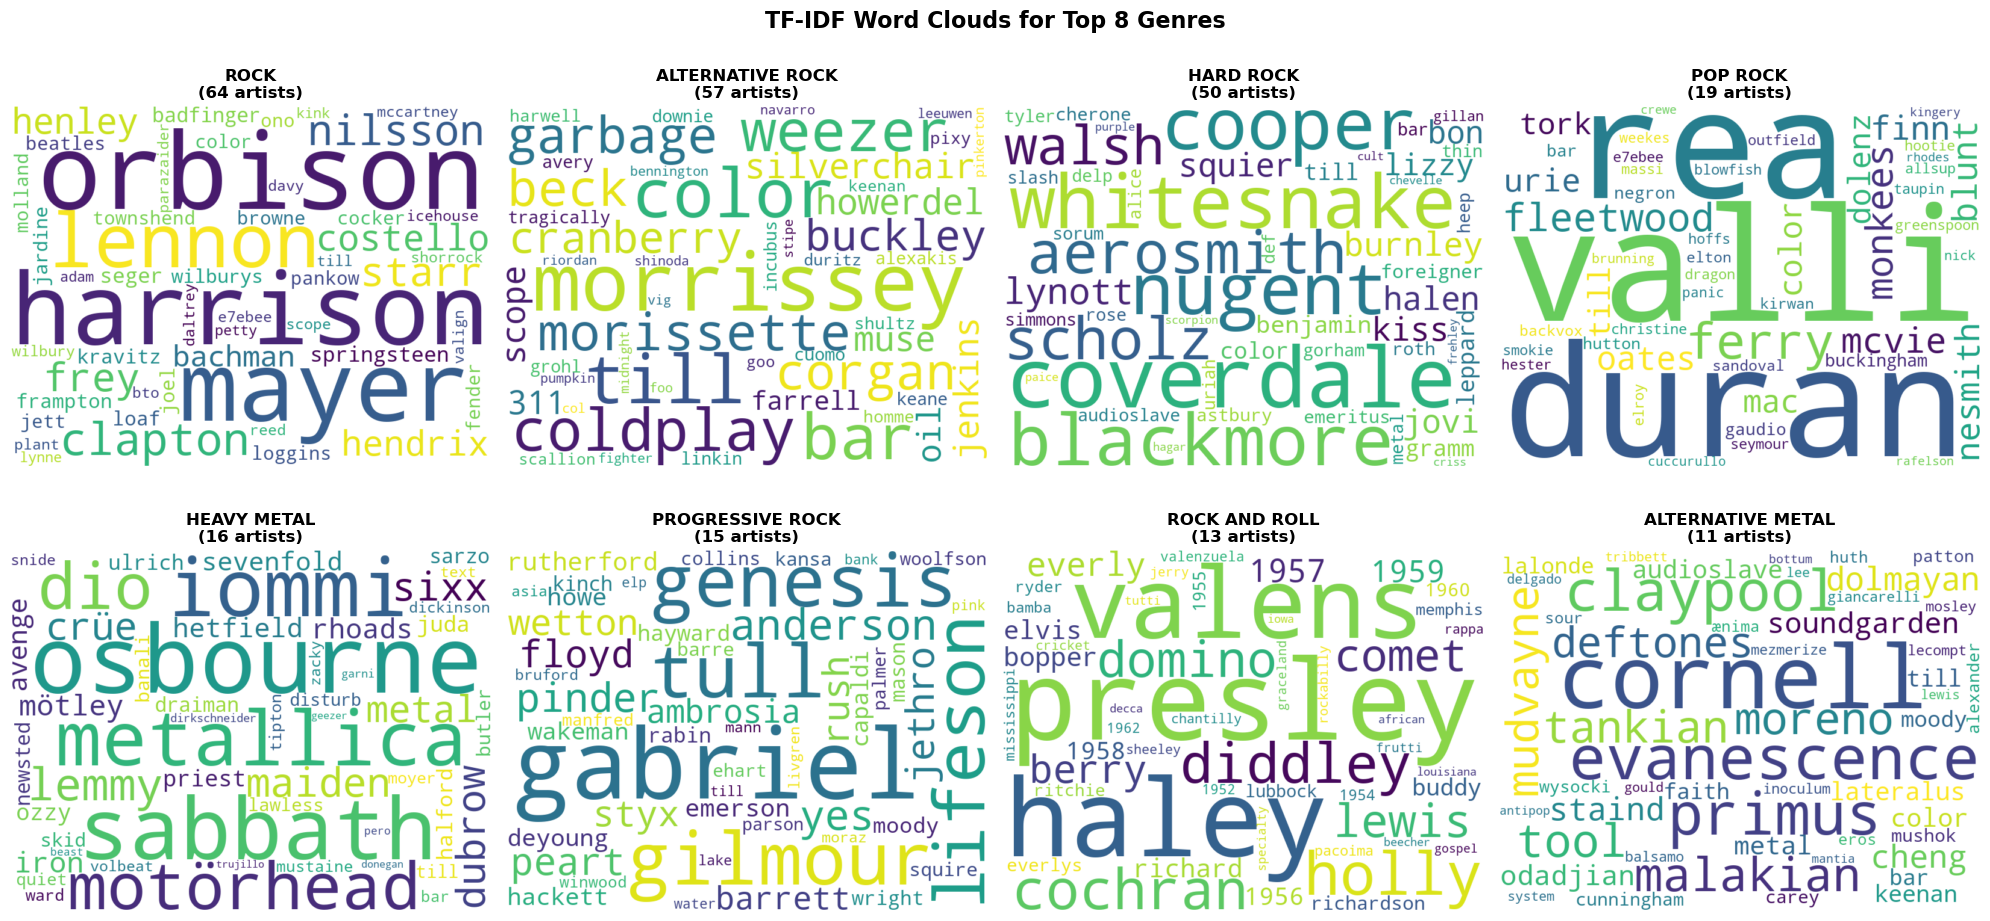

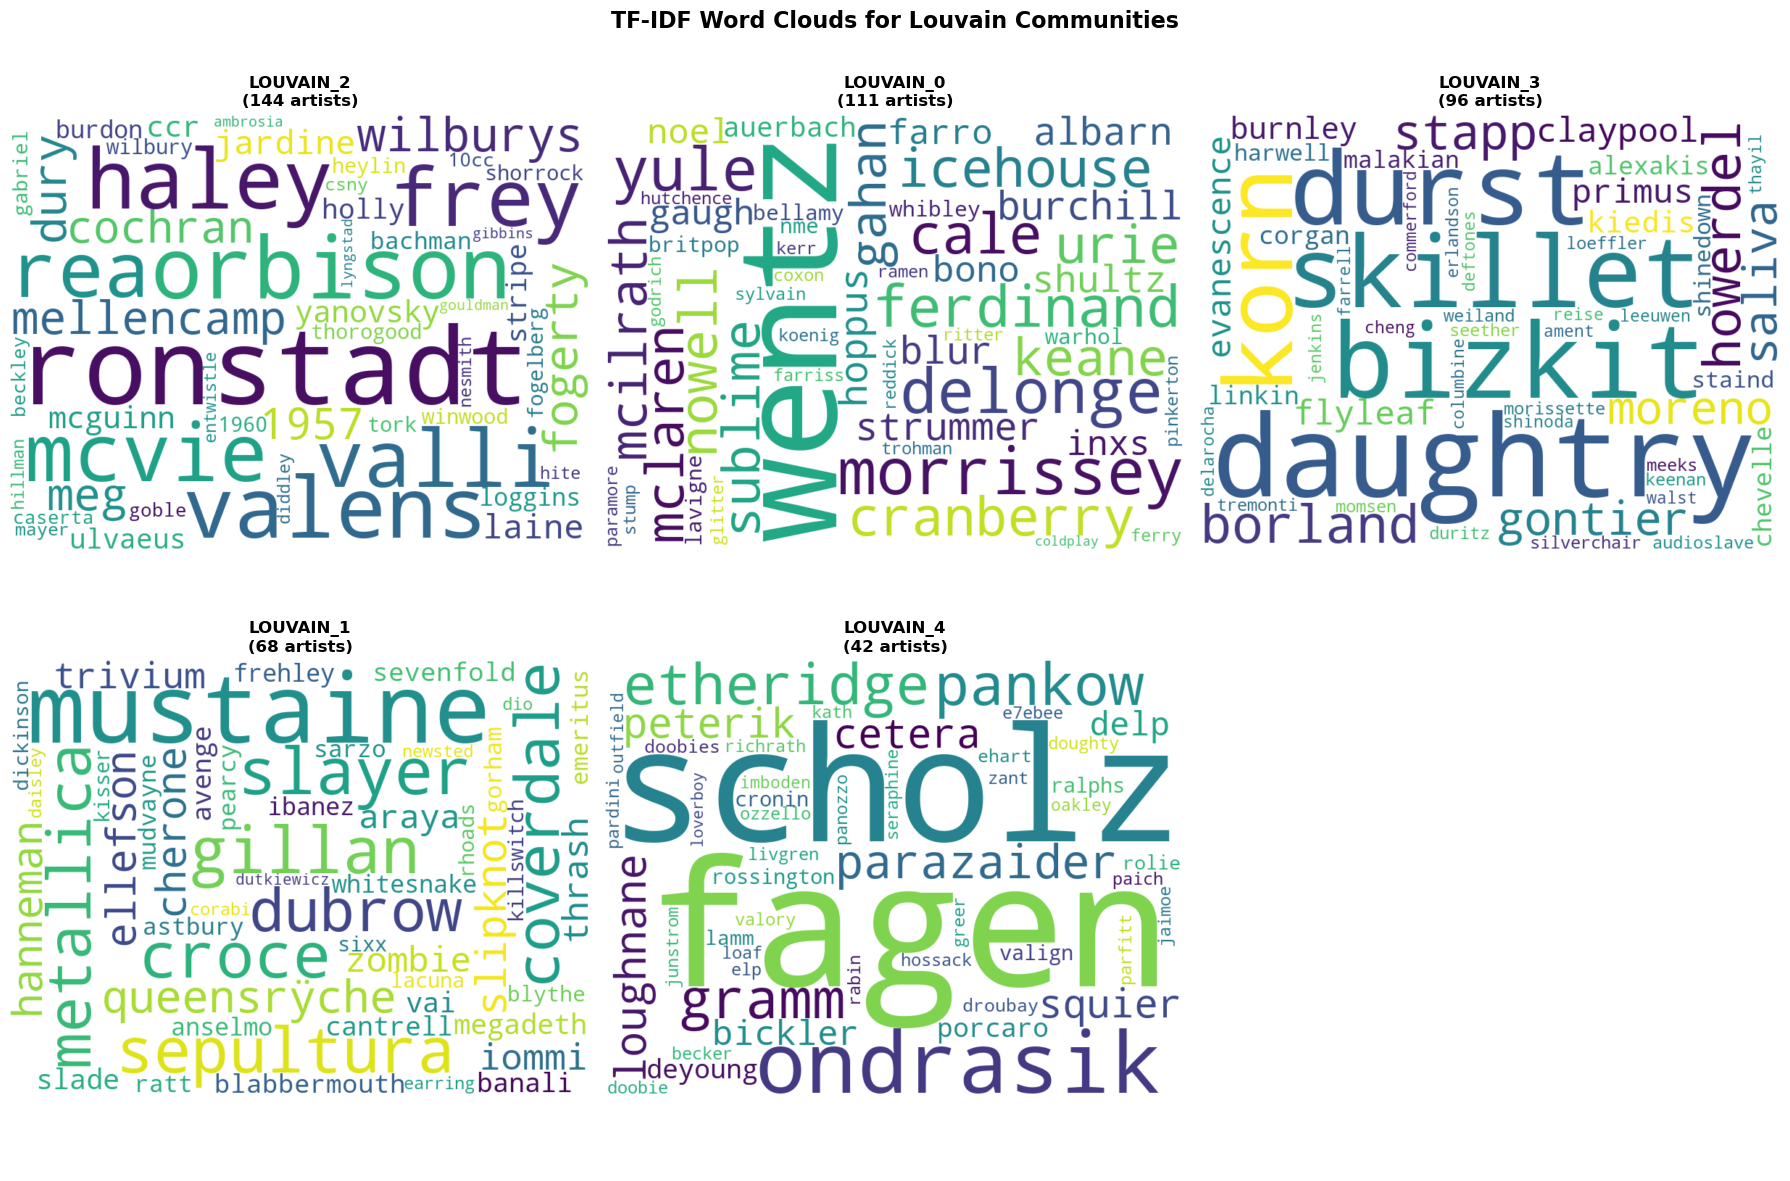

In [228]:
# Get top 8 genres by count
top_8_genres = [g[0] for g in genre_counts.most_common(8)]

# Create word clouds using TF-IDF scores for each of the top 8 genres
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, genre in enumerate(top_8_genres):
    # Get TF-IDF scores for this genre
    tfidf_scores = genre_tfidf[genre]
    
    # Find the max TF-IDF score for scaling
    max_tfidf = max([score for _, score in tfidf_scores])
    
    # Create frequency dictionary scaled for word cloud
    word_freq = {}
    for word, score in tfidf_scores:
        scaled_score = int((score / max_tfidf) * 100)
        if scaled_score > 0:
            word_freq[word] = scaled_score
    
    # Generate word cloud
    wc = WordCloud(
        width=800, 
        height=600,
        background_color='white',
        max_words=100,
        relative_scaling=0.5,
        min_font_size=10
    ).generate_from_frequencies(word_freq)
    
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'{genre.upper()}\n({genre_counts[genre]} artists)', 
                        fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('TF-IDF Word Clouds for Top 8 Genres', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


# Get all 5 Louvain communities
louvain_counts = node_df['Louvain'].value_counts()
all_louvain = [f"Louvain_{int(comm)}" for comm, count in louvain_counts.items()]

# Create word clouds for all Louvain communities
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, community in enumerate(all_louvain):
    # Get TF-IDF scores for this community
    tfidf_scores = louvain_tfidf[community]
    
    # Find the max TF-IDF score for scaling
    max_tfidf = max([score for _, score in tfidf_scores])
    
    # Create frequency dictionary scaled for word cloud
    word_freq = {}
    for word, score in tfidf_scores:
        scaled_score = int((score / max_tfidf) * 100)
        if scaled_score > 0:
            word_freq[word] = scaled_score
    
    # Generate word cloud
    wc = WordCloud(
        width=800, 
        height=600,
        background_color='white',
        max_words=100,
        relative_scaling=0.5,
        min_font_size=10
    ).generate_from_frequencies(word_freq)
    
    # Get community size
    comm_num = int(community.split('_')[1])
    comm_size = louvain_counts[comm_num]
    
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'{community.upper()}\n({comm_size} artists)', 
                        fontsize=12, fontweight='bold')
    axes[idx].axis('off')

# Hide the extra subplot (we have 5 communities but 6 subplots)
axes[5].axis('off')


plt.suptitle('TF-IDF Word Clouds for Louvain Communities', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


There are clear patterns in the word clouds across both types of communities:
- Last names dominate. Most of the names taking up the biggest stops are the last names of solo artists or the last names of influential members of groups. In rock the names of all four members of The Beatles are included.
- The most influential people often contributed to multiple groups/projects, meaning that they would have more than one page dedicated to them. Examples would be John Lennon, Ozzy Osbourne (solo and with Black Sabbath), Morrissey (Lead singer in The Smiths, and a notable solo act) and Dave Mustaine (guitarist in both Metallica and Megadeth).
- Rock and Roll was especially prevalent in the late sixties with the years 1955-1960 being significant.
- TF-IDF still leaves room for some weirdness: Duran shows up as a very important word in Pop rock but since the band is named Duran Duran, their TF would effectively be doubled. Likewise for the band Daughtry whose singer is called Chris Daughtry.

## 3.5 Comparison Using Matrix D

Some interesting patterns emerge when comparing the wordclouds with the D matrix. We saw earlier that Louvain_1 contains mostly hard rock and heavy metal. Now we can clearly see that the word cloud is dominated by words that also appear in the Heavy Metal genre word cloud (iommi, metallica, mustaine, etc.)

Similarly the fact that 12/13 Rock and Roll acts are in Louvain_2 along with most of the Rock acts means that the years 1957 and 1960 are significant in Louvain_2. This is combining the effect of Rock and Roll described above, with the fact that many influential Rock artists were big in the sixties (Harrison, Lennon, Clapton, Springsteen, etc).

For Louvain_3 it is interesting that the D matrix showed how it only had about half of the Alternative Rock artist and the word cloud for Louvain_3 contains very little overlap with Alternative Rock. This shows how Louvain_3 is dominated by the 46/93 acts that fall in genres not in the top 7 genres. A quick scan of the word cloud shows bands like Korn and Limp Bizkit, which aren't defined as Alternative Rock but something less popular (in terms of n).

In [233]:
# Find the first_genre for Limp Bizkit, Korn and Daughtry
for artist in ['Limp Bizkit', 'Korn', 'Daughtry (band)']:
        genre = node_df.loc[artist, 'first_genre']
        print(f"{artist}: {genre}")

Limp Bizkit: Nu metal
Korn: Nu metal
Daughtry (band): Post-grunge


---

# Part 4: Sentiment of the Artists and Communities

This section analyzes the sentiment of artist/band Wikipedia pages and explores how sentiment varies across communities.

## 4.1 Sentiment Calculation for Artist Pages

In [116]:
import pandas as pd
from IPython.display import display

labmt = pd.read_csv('lbmt_valence.txt', sep='\t', skiprows=3, header=0)
print(f"LabMT shape: {labmt.shape[0]:,} rows x {labmt.shape[1]} columns")
print("Columns:", ", ".join(labmt.columns))

with pd.option_context('display.max_columns', None, 'display.width', 0):
    print("\nFirst 5 rows (most positive words):")
    display(labmt.head())
    print("\nLast 5 rows:")
    display(labmt.tail())

LabMT shape: 10,222 rows x 8 columns
Columns: word, happiness_rank, happiness_average, happiness_standard_deviation, twitter_rank, google_rank, nyt_rank, lyrics_rank

First 5 rows (most positive words):


,word,happiness_rank,happiness_average,happiness_standard_deviation,twitter_rank,google_rank,nyt_rank,lyrics_rank
0,laughter,1,8.50,0.9313,3600,--,--,1728
1,happiness,2,8.44,0.9723,1853,2458,--,1230
2,love,3,8.42,1.1082,25,317,328,23
3,happy,4,8.30,0.9949,65,1372,1313,375
4,laughed,5,8.26,1.1572,3334,3542,--,2332



Last 5 rows:


,word,happiness_rank,happiness_average,happiness_standard_deviation,twitter_rank,google_rank,nyt_rank,lyrics_rank
10217,murder,10218,1.48,1.0150,2762,3110,1541,1059
10218,terrorism,10219,1.48,0.9089,--,--,3192,--
10219,rape,10220,1.44,0.7866,3133,--,4115,2977
10220,suicide,10221,1.30,0.8391,2124,4707,3319,2107
10221,terrorist,10222,1.30,0.9091,3576,--,3026,--


Defining a function that will take any list of tokens and return the average sentiment. Inspired by 'Temporal Patterns of Happiness and Information in a Global Social Network: Hedonometrics and Twitter' we also include the option of a delta parameter which will remove neutrally laden words within $[5-\delta, 5+\delta]$. 

Theoretically this increases the signal in the sample, making the differences statistically clearer, but in use we found that there wasn't a very noticable difference. The same artists and communities were low vs high, only the mean and median increased a bit.

**Reference:** Traud, A. L., Kelsic, E. D., Mucha, P. J., & Porter, M. A. (2011). Comparing Community Structure to Characteristics in Online Collegiate Social Networks. *PLOS ONE*, 6(11), e26752. https://doi.org/10.1371/journal.pone.0026752

## 4.2 Statistical Analysis of Sentiment

We start by defining a function to get the average sentiment of a list of tokens. This way we can call it both on individual artists and on the communities.

In [118]:
def calculate_sentiment(tokens, delta=0, verbose=False):
    """
    Calculate sentiment given a list of tokens.
    """
    # Create a dictionary for faster lookup
    sentiment_dict = dict(zip(labmt['word'], labmt['happiness_average']))
    
    # Apply delta filter: keep only words outside the neutral range [5-delta, 5+delta]
    if delta > 0:
        sentiment_dict = {
            word: score 
            for word, score in sentiment_dict.items() 
            if abs(score - 5) > delta
        }
    
    # Convert tokens to lowercase
    tokens = [token.lower() for token in tokens]
    
    # Get sentiment scores for tokens that exist in filtered LabMT
    sentiments = [sentiment_dict[token] for token in tokens if token in sentiment_dict]
    
    # Calculate average sentiment
    if sentiments:
        avg_sentiment = sum(sentiments) / len(sentiments)
    else:
        raise ValueError("No sentiments found: none of the tokens matched the LabMT lexicon.")
    
    # Print individual scores for short lists
    if verbose and len(tokens) <= 20:
        print(f"Using delta={delta} (removing words with scores between {5-delta} and {5+delta})")
        print("Individual word sentiments:")
        for token in tokens:
            if token in sentiment_dict:
                print(f"  {token}: {sentiment_dict[token]:.2f}")
            else:
                original_score = dict(zip(labmt['word'], labmt['happiness_average'])).get(token)
                if original_score is not None:
                    print(f"  {token}: {original_score:.2f} (filtered out by delta)")
                else:
                    print(f"  {token}: not found in LabMT")
        print(f"\nAverage sentiment: {avg_sentiment:.2f}")
        print(f"Words used in calculation: {len(sentiments)}/{len(tokens)}")
    elif verbose:
        print(f"Using delta={delta}")
        print(f"Average sentiment: {avg_sentiment:.2f}")
        print(f"Words used: {len(sentiments)}/{len(tokens)}")
    
    return avg_sentiment

In [119]:
with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/graphs/rock_bands_graph.gexf") as response:
    DG = nx.read_gexf(response)

G = DG.to_undirected()

In [ ]:
import os

# Create dictionaries to store sentiment scores for different delta values
artist_sentiments_by_delta = {}

for delta in [0, 1]:
    artist_sentiments_by_delta[delta] = {}
    
    for node in G.nodes():
        filename = urllib.parse.quote(node, safe="") + ".txt"
        file_path = os.path.join("rock_data", filename)
        
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()
        except FileNotFoundError:
            print(f"File not found for artist: {node}")
            artist_sentiments_by_delta[delta][node] = float("nan")
            continue
        except Exception as e:
            print(f"Error reading file for artist '{node}': {e}")
            artist_sentiments_by_delta[delta][node] = float("nan")
            continue

        tokens = preprocess_text(content)
        try:
            sentiment = calculate_sentiment(tokens, delta=delta)
            artist_sentiments_by_delta[delta][node] = sentiment
        except ValueError:
            print(f"No sentiment calculated for artist: {node} (delta={delta})")
            artist_sentiments_by_delta[delta][node] = float("nan")

print(f"\nCompleted sentiment analysis for {len(G.nodes())} artists with delta values: {list(artist_sentiments_by_delta.keys())}")
import pickle

# Save artist_sentiments dictionary as a pickle file
with open('artist_sentiments_by_delta.pkl', 'wb') as f:
    pickle.dump(artist_sentiments_by_delta, f)




Completed sentiment analysis for 461 artists with delta values: [0, 1]


Looking at statistical description for delta = 0, to talk about the general characteristics of the wikipedia pages of rock performers.

In [246]:
# Statistical analysis for delta = 0
delta = 0
sentiment_series = pd.Series(artist_sentiments_by_delta[delta], name="sentiment").sort_values()

print(f"\n{'='*60}")
print(f"Statistical Analysis for Delta = {delta}")
print(f"{'='*60}")
print(f"\nTotal artists: {len(sentiment_series)}")
print(f"Missing values: {sentiment_series.isna().sum()}")

# Descriptive statistics
print(f"\n--- Descriptive Statistics ---")
print(f"Mean:     {sentiment_series.mean():.4f}")
print(f"Median:   {sentiment_series.median():.4f}")
print(f"Std Dev:  {sentiment_series.std():.4f}")
print(f"Min:      {sentiment_series.min():.4f}")
print(f"Max:      {sentiment_series.max():.4f}")
print(f"Range:    {sentiment_series.max() - sentiment_series.min():.4f}")

# Quartiles
print(f"\n--- Quartiles ---")
print(f"25th percentile: {sentiment_series.quantile(0.25):.4f}")
print(f"50th percentile: {sentiment_series.quantile(0.50):.4f}")
print(f"75th percentile: {sentiment_series.quantile(0.75):.4f}")
print(f"IQR:             {sentiment_series.quantile(0.75) - sentiment_series.quantile(0.25):.4f}")


Statistical Analysis for Delta = 0

Total artists: 461
Missing values: 0

--- Descriptive Statistics ---
Mean:     5.8426
Median:   5.8475
Std Dev:  0.0800
Min:      5.6028
Max:      6.1113
Range:    0.5085

--- Quartiles ---
25th percentile: 5.7912
50th percentile: 5.8475
75th percentile: 5.8941
IQR:             0.1028


The data suggesst that many pages are quite similar with a slightly positive tone, indicating that most articles are generally highlighting the positives and notable rock performers would tend to include those that are a positive influence on the genre more than rock performers with a lot of scandals.

The max and mix being $\approx 0.5$ apart suggests that when entire articles are considered they tend to not be very dissimilar even when filtering for stop words which would strengthen this effect.

Seeing that the IQR is much smaller than the min and max would suggest that we have some outliers which would be interesting to look into.

## 4.3 Visualization of Sentiment Distribution

We plot the histogram for delta = 0. We also overlay the statistical findings from above.

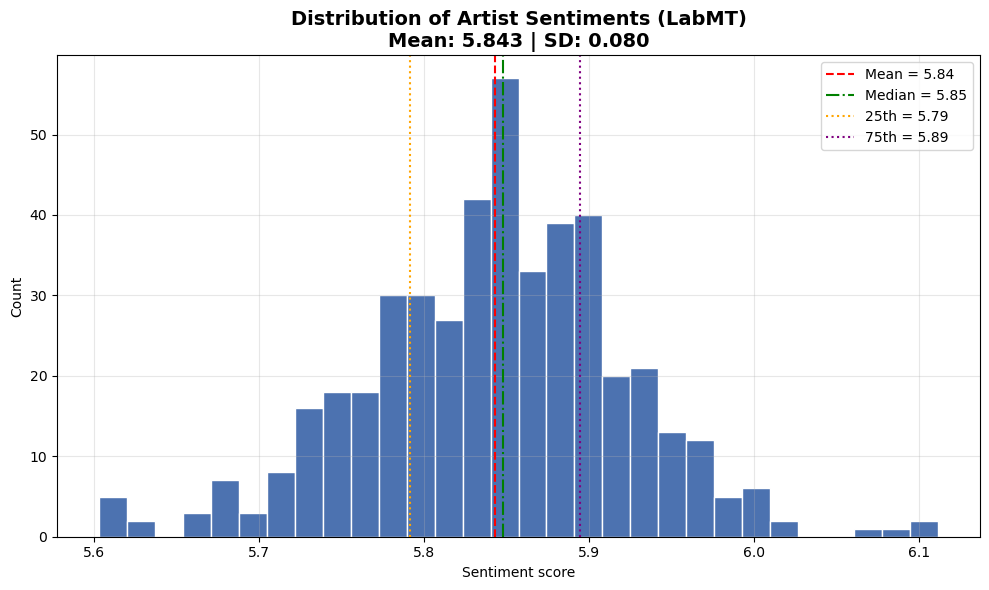

In [248]:
# Load the artist_sentiments_by_delta dictionary from GitHub
with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/artist_sentiments_by_delta.pkl") as response:
    artist_sentiments_by_delta = pickle.load(response)

# Get the sentiment data for delta = 0
sentiment_series = pd.Series(artist_sentiments_by_delta[0], name="sentiment").sort_values()

# Calculate statistics
mean_val = sentiment_series.mean()
median_val = sentiment_series.median()
q25 = sentiment_series.quantile(0.25)
q75 = sentiment_series.quantile(0.75)
std_val = sentiment_series.std()

# Create single plot
plt.figure(figsize=(10, 6))
plt.hist(sentiment_series.values, bins=30, color="#4C72B0", edgecolor="white")
plt.axvline(mean_val, color="red", linestyle="--", label=f"Mean = {mean_val:.2f}")
plt.axvline(median_val, color="green", linestyle="-.", label=f"Median = {median_val:.2f}")
plt.axvline(q25, color="orange", linestyle=":", label=f"25th = {q25:.2f}")
plt.axvline(q75, color="purple", linestyle=":", label=f"75th = {q75:.2f}")
plt.title(f"Distribution of Artist Sentiments (LabMT)\nMean: {mean_val:.3f} | SD: {std_val:.3f}", fontsize=14, fontweight='bold')
plt.xlabel("Sentiment score")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The distribution looks very similar to a normal with some outliers on either end. Even the most negative articles are still higher than 5 which is the neutral point of the scale. This would again suggest that Wikipedia strives to describe the subjects in neutral terms, but that the nature of the most notable bands mean that they're still more positive than negative. Additionally, we suspect that the more formal language of a Wikipedia article would also skew this to be more positive.

Having looked at the entire populatioj, it is time to look closer at the extreme artists:

In [242]:
# Print summary statistics for just delta = 0
delta = 0
sentiment_series = pd.Series(artist_sentiments_by_delta[delta], name="sentiment").sort_values()
print(f"\n{'='*60}")
print(f"DELTA = {delta}")
print(f"{'='*60}")
print(f"Total artists: {len(sentiment_series)}")
print(f"\nBottom 10 artists:")
print(sentiment_series.head(10).to_string())
print(f"\nTop 10 artists:")
print(sentiment_series.tail(10).sort_values(ascending=False).to_string())

mean_val = sentiment_series.mean()
median_val = sentiment_series.median()
q25 = sentiment_series.quantile(0.25)
q75 = sentiment_series.quantile(0.75)
std_val = sentiment_series.std()
print(f"\nMean: {mean_val:.3f} | Median: {median_val:.3f} | SD: {std_val:.3f} | 25th percentile: {q25:.3f} | 75th percentile: {q75:.3f}")


DELTA = 0
Total artists: 461

Bottom 10 artists:
Five Finger Death Punch     5.602804
Ted Nugent                  5.604895
Sex Pistols                 5.606636
Rob Zombie                  5.608339
Gary Glitter                5.608370
Skid Row (American band)    5.627613
Marilyn Manson              5.635188
Gene Vincent                5.654282
Quiet Riot                  5.659775
White Zombie (band)         5.663769

Top 10 artists:
Lenny Kravitz      6.111301
Tracy Chapman      6.099917
Fun (band)         6.088067
The Cardigans      6.066594
Travis (band)      6.023129
Simple Plan        6.019708
Mumford & Sons     6.007190
Boys Like Girls    6.000024
Counting Crows     5.998266
Train (band)       5.998101

Mean: 5.843 | Median: 5.848 | SD: 0.080 | 25th percentile: 5.791 | 75th percentile: 5.894


Clearly having a negative word in the band name is not good for the sentiment (with half the most negative artist having negatively laden names) but is it just because of the name or do artists with low sentiment names also have more negative wikipedia articles?

Let's see what kind of words makes the top three artists on either end stand out.


Five Finger Death Punch
Overall sentiment: 5.603

  Most NEGATIVE words (appearing >2 times):
    death                1.54  (233x)
    war                  1.80  ( 10x)
    dying                2.10  (  3x)
    hell                 2.22  ( 17x)
    destruction          2.26  (  3x)

  Most POSITIVE words (appearing >2 times):
    successful           8.16  (  3x)
    won                  8.10  ( 23x)
    music                8.02  ( 37x)
    heaven               7.86  ( 28x)
    festival             7.70  ( 18x)

Ted Nugent
Overall sentiment: 5.605

  Most NEGATIVE words (appearing >2 times):
    kill                 1.56  (  3x)
    died                 1.56  (  6x)
    war                  1.80  ( 10x)
    evil                 1.90  (  3x)
    dead                 2.00  ( 11x)

  Most POSITIVE words (appearing >2 times):
    love                 8.42  (  7x)
    music                8.02  ( 18x)
    weekend              8.00  (  3x)
    free                 7.96  ( 10x)
    hero   

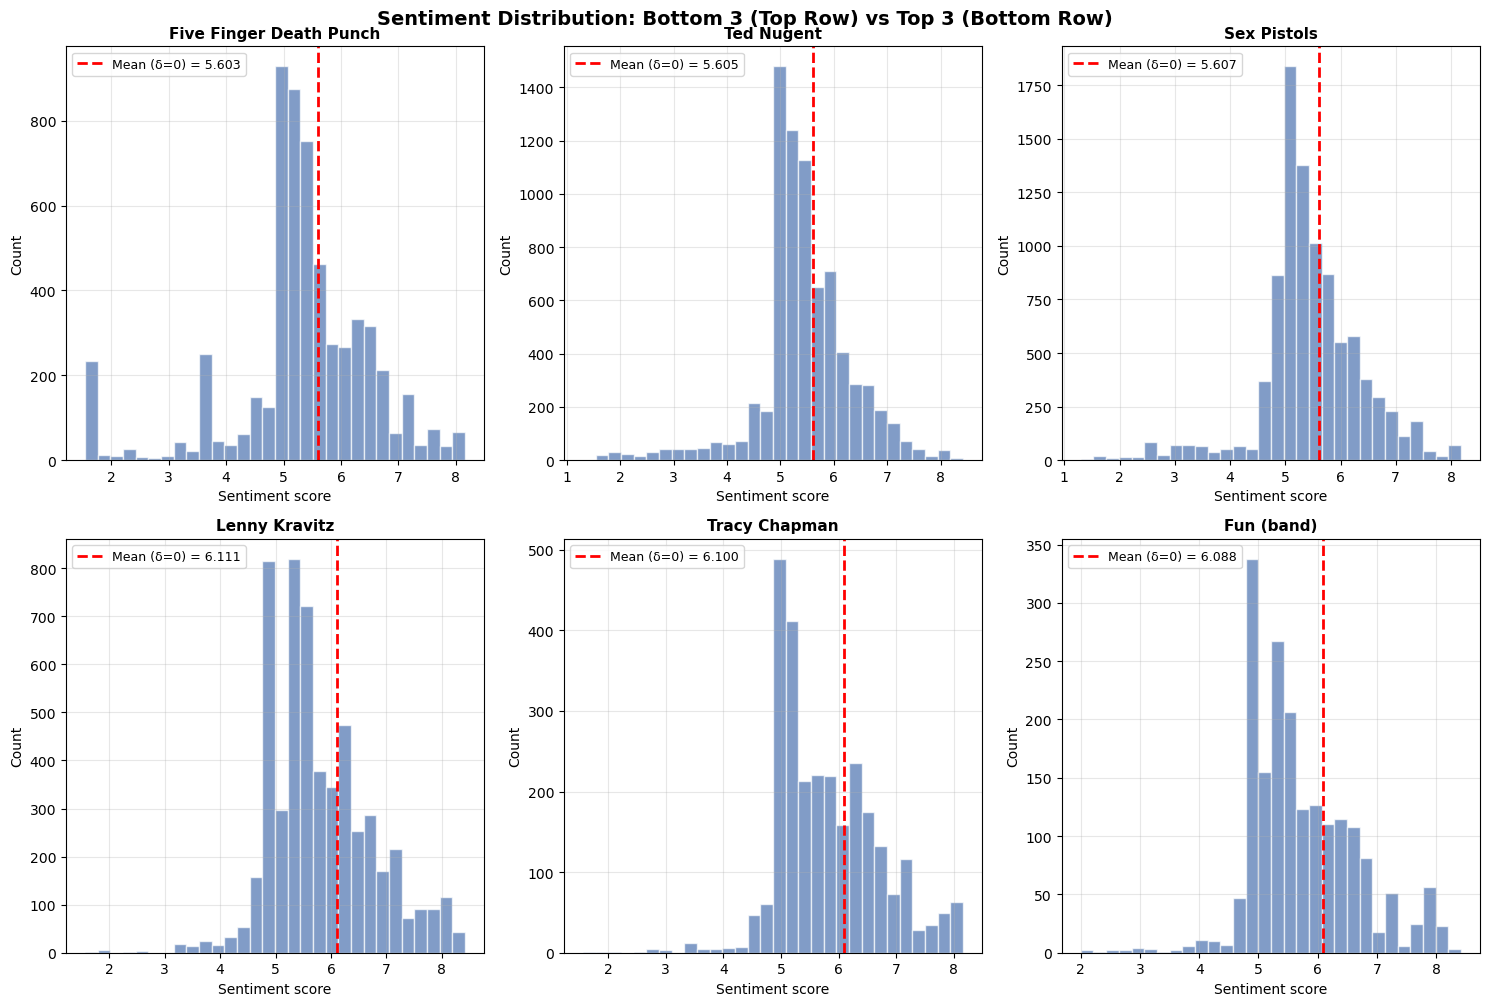

In [251]:
# Get top 3 and bottom 3 artists
top_3 = sentiment_series.tail(3).sort_values(ascending=False)
bottom_3 = sentiment_series.head(3)

# Create sentiment dictionary for lookup
sentiment_dict = dict(zip(labmt['word'], labmt['happiness_average']))

# Function to find extreme words
def analyze_extreme_words(artist_name, n_words=10):
    filename = urllib.parse.quote(artist_name, safe="")
    with open(f"rock_data/{filename}.txt", "r", encoding="utf-8") as f:
        content = f.read()
        tokens = word_tokenize(content)
        tokens_lower = [token.lower() for token in tokens]
        
        # Get tokens that are in LabMT
        scored_tokens = [(token, sentiment_dict[token]) for token in tokens_lower if token in sentiment_dict]
        
        # Count frequencies
        token_freq = Counter([token for token, _ in scored_tokens])
        
        # Get unique tokens with scores (only those appearing more than once)
        unique_scored = {token: score for token, score in scored_tokens if token_freq[token] > 2}
        
        # Sort by sentiment score
        sorted_tokens = sorted(unique_scored.items(), key=lambda x: x[1])
        
        return sorted_tokens, token_freq

# Analyze all 6 artists (top 3 and bottom 3)
all_artists = list(bottom_3.index) + list(top_3.index)

for artist in all_artists:
    sentiment_score = sentiment_series[artist]
    print(f"\n{'='*70}")
    print(f"{artist}")
    print(f"Overall sentiment: {sentiment_score:.3f}")
    print(f"{'='*70}")
    
    sorted_tokens, token_freq = analyze_extreme_words(artist)
    
    print(f"\n  Most NEGATIVE words (appearing >2 times):")
    for token, score in sorted_tokens[:5]:
        print(f"    {token:20s} {score:.2f}  ({token_freq[token]:3d}x)")
    
    print(f"\n  Most POSITIVE words (appearing >2 times):")
    for token, score in reversed(sorted_tokens[-5:]):
        print(f"    {token:20s} {score:.2f}  ({token_freq[token]:3d}x)")

# Get all 6 artists (top 3 and bottom 3)
all_artists = list(bottom_3.index) + list(top_3.index)

# Create sentiment dictionary for lookup
sentiment_dict = dict(zip(labmt['word'], labmt['happiness_average']))

# Create 2x3 subplot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, artist in enumerate(all_artists):
    filename = urllib.parse.quote(artist, safe="")
    with open(f"rock_data/{filename}.txt", "r", encoding="utf-8") as f:
        content = f.read()
        tokens = word_tokenize(content)
        tokens_lower = [token.lower() for token in tokens]
        
        # Get sentiment scores for tokens that exist in LabMT
        sentiments = [sentiment_dict[token] for token in tokens_lower if token in sentiment_dict]
        
        # Plot histogram
        axes[idx].hist(sentiments, bins=30, color="#4C72B0", edgecolor="white", alpha=0.7)
        axes[idx].axvline(artist_sentiments[artist], color="red", linestyle="--", linewidth=2, 
                         label=f"Mean (δ=0) = {artist_sentiments[artist]:.3f}")

        axes[idx].set_title(f"{artist}", fontsize=11, fontweight='bold')
        axes[idx].set_xlabel("Sentiment score")
        axes[idx].set_ylabel("Count")
        axes[idx].legend(fontsize=9)
        axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("Sentiment Distribution: Bottom 3 (Top Row) vs Top 3 (Bottom Row)", 
             fontsize=14, fontweight='bold', y=1.002)
plt.show()

The three artists with the most negative sentiment (Five Finger Death Punch, Ted Nugent, Sex Pistols) show violent and dark vocabulary—"death," "murder," "kill," "war"—appearing frequently throughout their Wikipedia articles, not just in their band names. It should be noted that for Five Finger Death Punch, the two bins showing 200+ occurrences with valence ≈1.5 and ≈2.0 are primarily due to their band name, whereas Ted Nugent and Sex Pistols exhibit a broader spread across negative terms. Had Five Finger Death Punch been named "Two Arm Love Hug," they would likely rank considerably higher in sentiment.

In contrast, the three most positive artists (Lenny Kravitz, Tracy Chapman, Fun) emphasize achievement and creativity, with words like "love," "won," "music," and "award" dominating their pages. This suggests that sentiment scores reflect the actual content and themes of these artists' careers and public personas.

Upon closer inspection, the Sex Pistols' article discusses arrests and murder, while Tracy Chapman's focuses on awards and success. Sentiment analysis has efficiently quantified both, providing an effective method to understand the tone surrounding individual artists as well as entire communities.

## 4.4 Sentiment Analysis by Community

/var/folders/7f/_d1gswbx4hngxw3tp2m2k9kr0000gn/T/ipykernel_23863/3632586979.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(genres, rotation=45, ha='right')


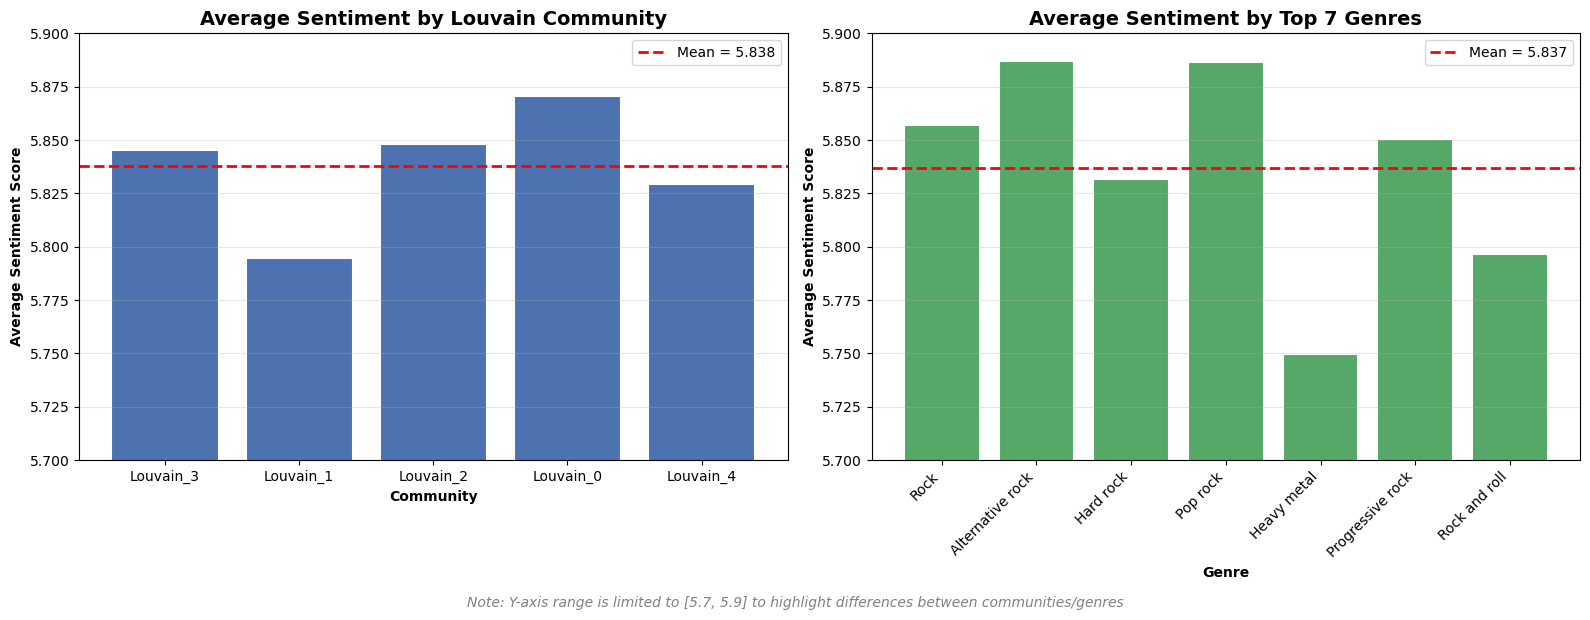


LOUVAIN COMMUNITIES:
----------------------------------------------------------------------
Louvain_0      : 5.8706  (n=108 artists)
Louvain_1      : 5.7949  (n= 66 artists)
Louvain_2      : 5.8480  (n=132 artists)
Louvain_3      : 5.8454  (n= 93 artists)
Louvain_4      : 5.8292  (n= 41 artists)

Mean: 5.8376
Std:  0.0251
Range: [5.7949, 5.8706]
TOP 7 GENRES:
----------------------------------------------------------------------
Rock                : 5.8569  (n= 64 artists)
Alternative rock    : 5.8870  (n= 57 artists)
Hard rock           : 5.8317  (n= 50 artists)
Pop rock            : 5.8867  (n= 19 artists)
Heavy metal         : 5.7496  (n= 16 artists)
Progressive rock    : 5.8507  (n= 15 artists)
Rock and roll       : 5.7968  (n= 13 artists)

Mean: 5.8371
Std:  0.0460
Range: [5.7496, 5.8870]


In [162]:
import matplotlib.pyplot as plt

# Get sentiment scores for delta=0
artist_sentiments = artist_sentiments_by_delta[0]

# Calculate average sentiment for each Louvain community
louvain_sentiment_scores = {}
for community, artists in louvain_communities.items():
    sentiments = [artist_sentiments[artist] for artist in artists if artist in artist_sentiments and not pd.isna(artist_sentiments[artist])]
    if sentiments:
        louvain_sentiment_scores[community] = np.mean(sentiments)

# Calculate average sentiment for top 7 genres
top_7_genres = [g[0] for g in genre_counts.most_common(7)]
genre_sentiment_scores = {}
for genre in top_7_genres:
    if genre in first_genre_communities:
        artists = first_genre_communities[genre]
        sentiments = [artist_sentiments[artist] for artist in artists if artist in artist_sentiments and not pd.isna(artist_sentiments[artist])]
        if sentiments:
            genre_sentiment_scores[genre] = np.mean(sentiments)

# Create comparison visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Louvain communities
communities = list(louvain_sentiment_scores.keys())
louvain_scores = list(louvain_sentiment_scores.values())
ax1.bar(communities, louvain_scores, color='#4C72B0', edgecolor='white', linewidth=1.5)
ax1.axhline(np.mean(louvain_scores), color='red', linestyle='--', linewidth=2, label=f'Mean = {np.mean(louvain_scores):.3f}')
ax1.set_xlabel('Community', fontweight='bold')
ax1.set_ylabel('Average Sentiment Score', fontweight='bold')
ax1.set_title('Average Sentiment by Louvain Community', fontweight='bold', fontsize=14)
ax1.set_ylim([5.7, 5.9])
ax1.legend()
ax1.grid(alpha=0.3, axis='y')

# Plot top 7 genres
genres = list(genre_sentiment_scores.keys())
genre_scores = list(genre_sentiment_scores.values())
ax2.bar(genres, genre_scores, color='#55A868', edgecolor='white', linewidth=1.5)
ax2.axhline(np.mean(genre_scores), color='red', linestyle='--', linewidth=2, label=f'Mean = {np.mean(genre_scores):.3f}')
ax2.set_xlabel('Genre', fontweight='bold')
ax2.set_ylabel('Average Sentiment Score', fontweight='bold')
ax2.set_title('Average Sentiment by Top 7 Genres', fontweight='bold', fontsize=14)
ax2.set_ylim([5.7, 5.9])
ax2.set_xticklabels(genres, rotation=45, ha='right')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()

# Add note about y-axis range
fig.text(0.5, -0.02, 'Note: Y-axis range is limited to [5.7, 5.9] to highlight differences between communities/genres', 
         ha='center', fontsize=10, style='italic', color='gray')

plt.show()


print("\nLOUVAIN COMMUNITIES:")
print("-"*70)
for community in sorted(louvain_sentiment_scores.keys()):
    score = louvain_sentiment_scores[community]
    size = len(louvain_communities[community])
    print(f"{community:15s}: {score:.4f}  (n={size:3d} artists)")
print(f"\nMean: {np.mean(louvain_scores):.4f}")
print(f"Std:  {np.std(louvain_scores):.4f}")
print(f"Range: [{min(louvain_scores):.4f}, {max(louvain_scores):.4f}]")

print("TOP 7 GENRES:")
print("-"*70)
for genre in top_7_genres:
    if genre in genre_sentiment_scores:
        score = genre_sentiment_scores[genre]
        size = len(first_genre_communities[genre])
        print(f"{genre:20s}: {score:.4f}  (n={size:3d} artists)")
print(f"\nMean: {np.mean(genre_scores):.4f}")
print(f"Std:  {np.std(genre_scores):.4f}")
print(f"Range: [{min(genre_scores):.4f}, {max(genre_scores):.4f}]")

The sentiment analysis reveals remarkably little variation across both structural communities (range: 5.79-5.87) and genres (range: 5.75-5.89), with all groups clustering tightly around the overall mean of 5.84.
Heavy metal stands out as the most negative genre (5.75), aligning with our earlier observation that artists in this category frequently discuss darker themes, while alternative rock and pop rock are slightly more positive (5.88).

Structural communities show even less differentiation than genres, with Louvain_1 (5.79) (which our confusion matrix revealed as the heavy metal/hard rock community) being marginally more negative than others. 
The narrow standard deviations (0.025 for communities, 0.046 for genres) confirm that Wikipedia's neutral editorial tone successfully moderates sentiment differences across the rock music landscape. 

Despite different musical styles and cultural associations, Wikipedia treats all rock artists with remarkably uniform positivity, suggesting that encyclopedic writing overrides genre-specific themes. A similar study could be done on the lyrics of the artist, and would probably reveal a far bigger variance.

---

## Conclusion

[Summarize the key findings from all four parts of the assignment and reflect on what was learned about the Rock Musicians network.]